In [ ]:
!pip install flask-cors

In [ ]:
from flask_cors import CORS
from flask import Flask
app = Flask(__name__)
CORS(app)


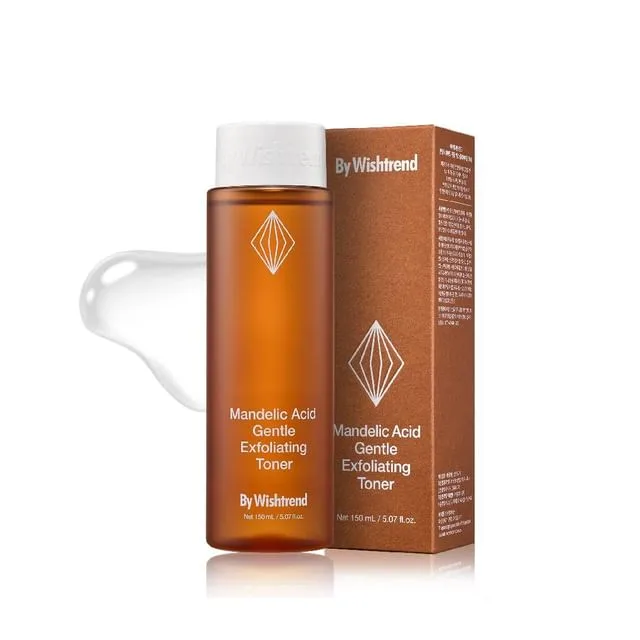
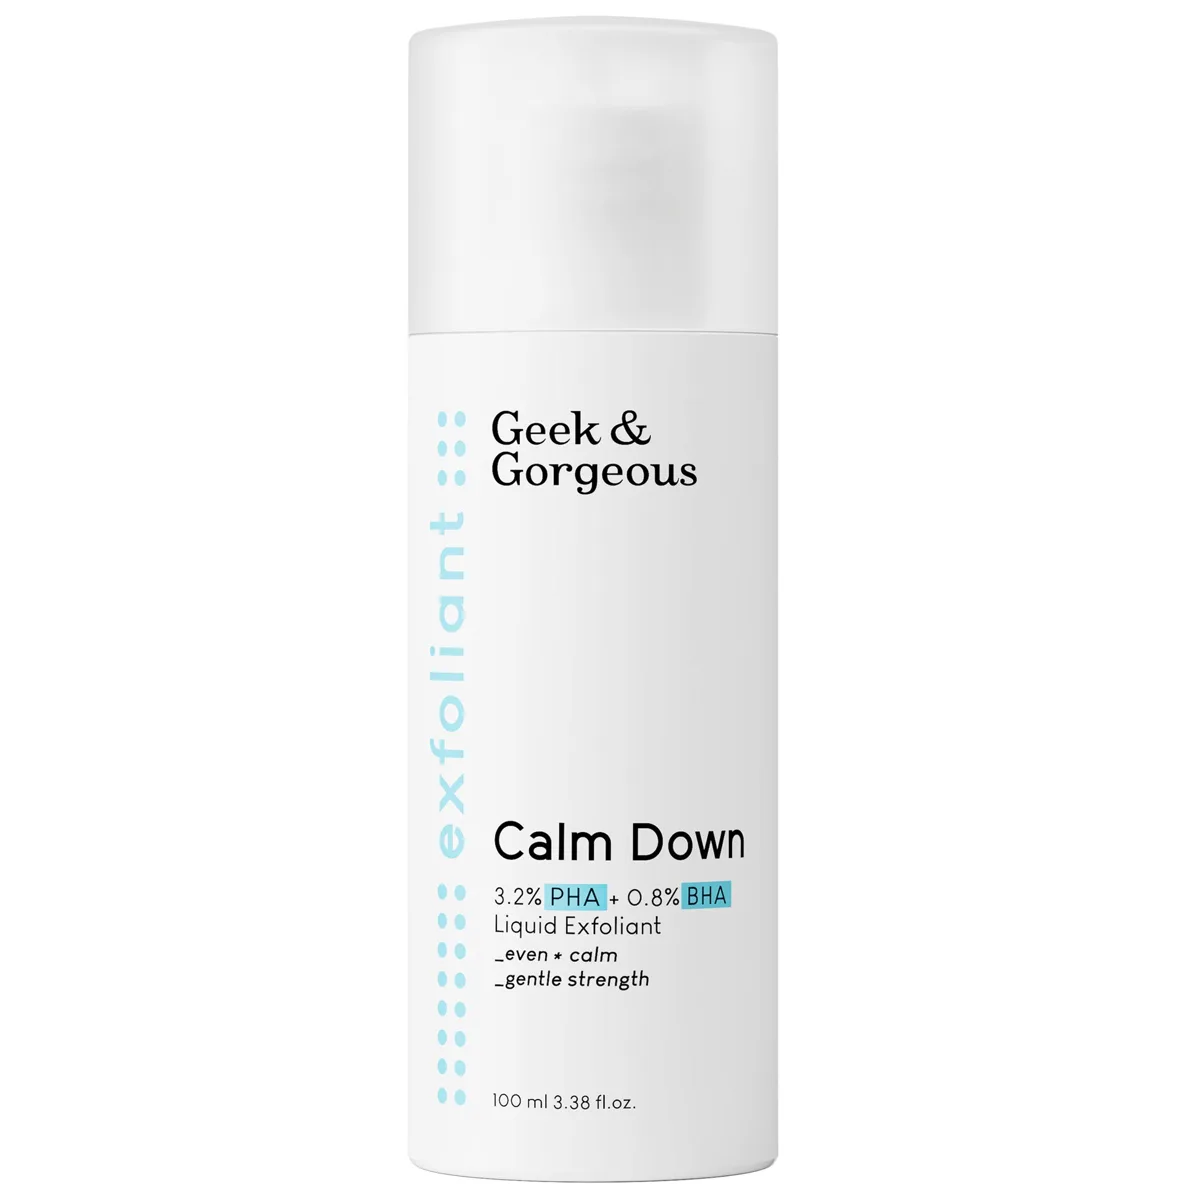
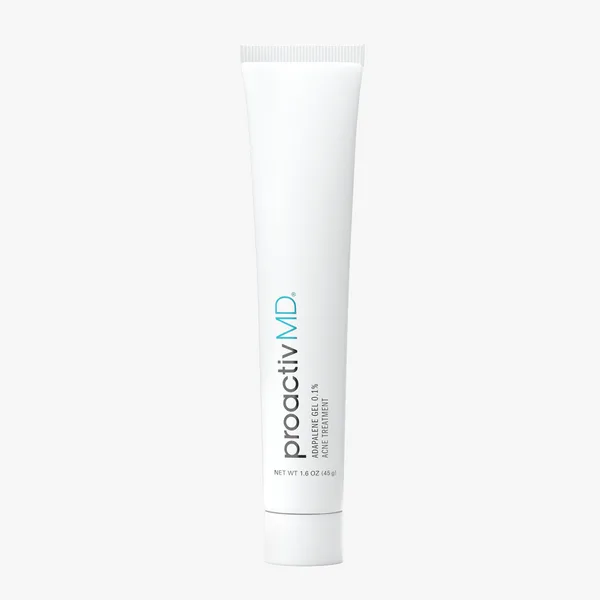
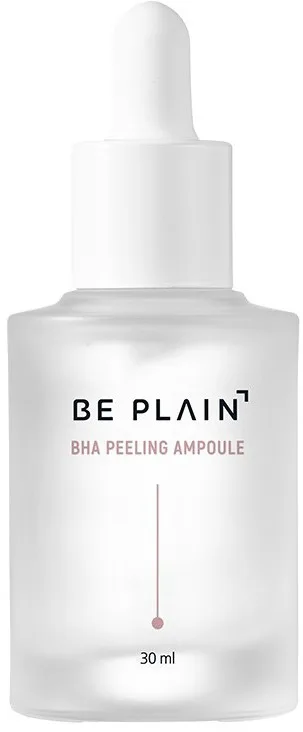
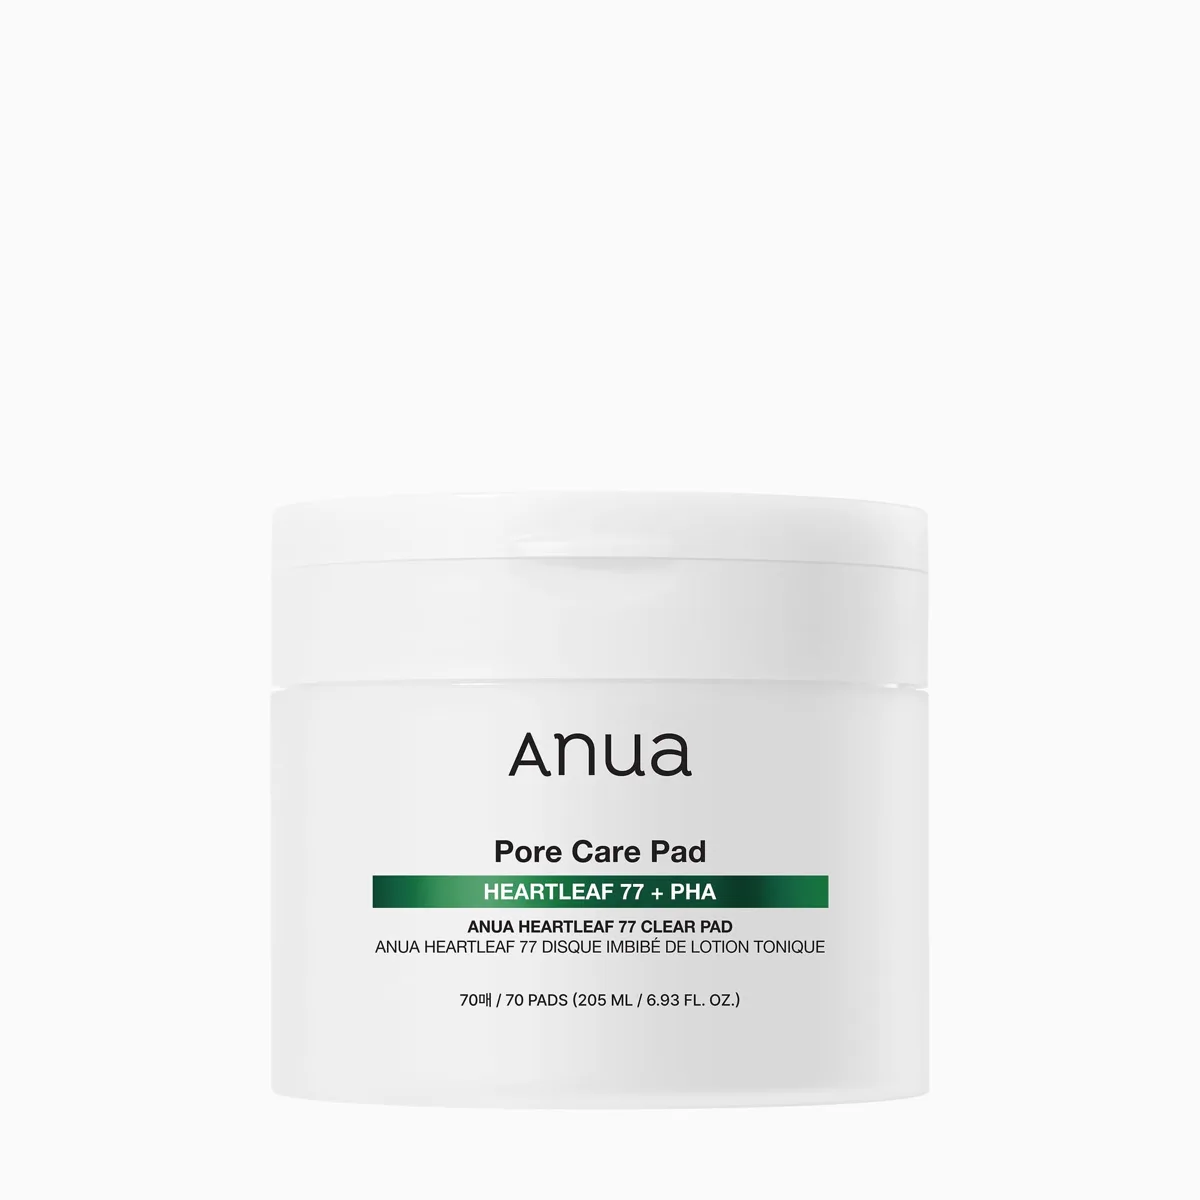
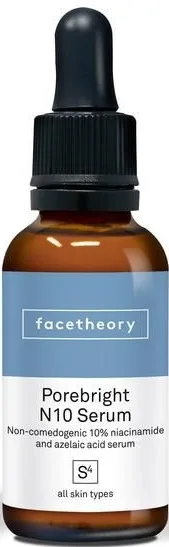
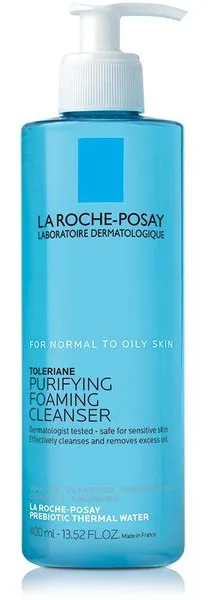
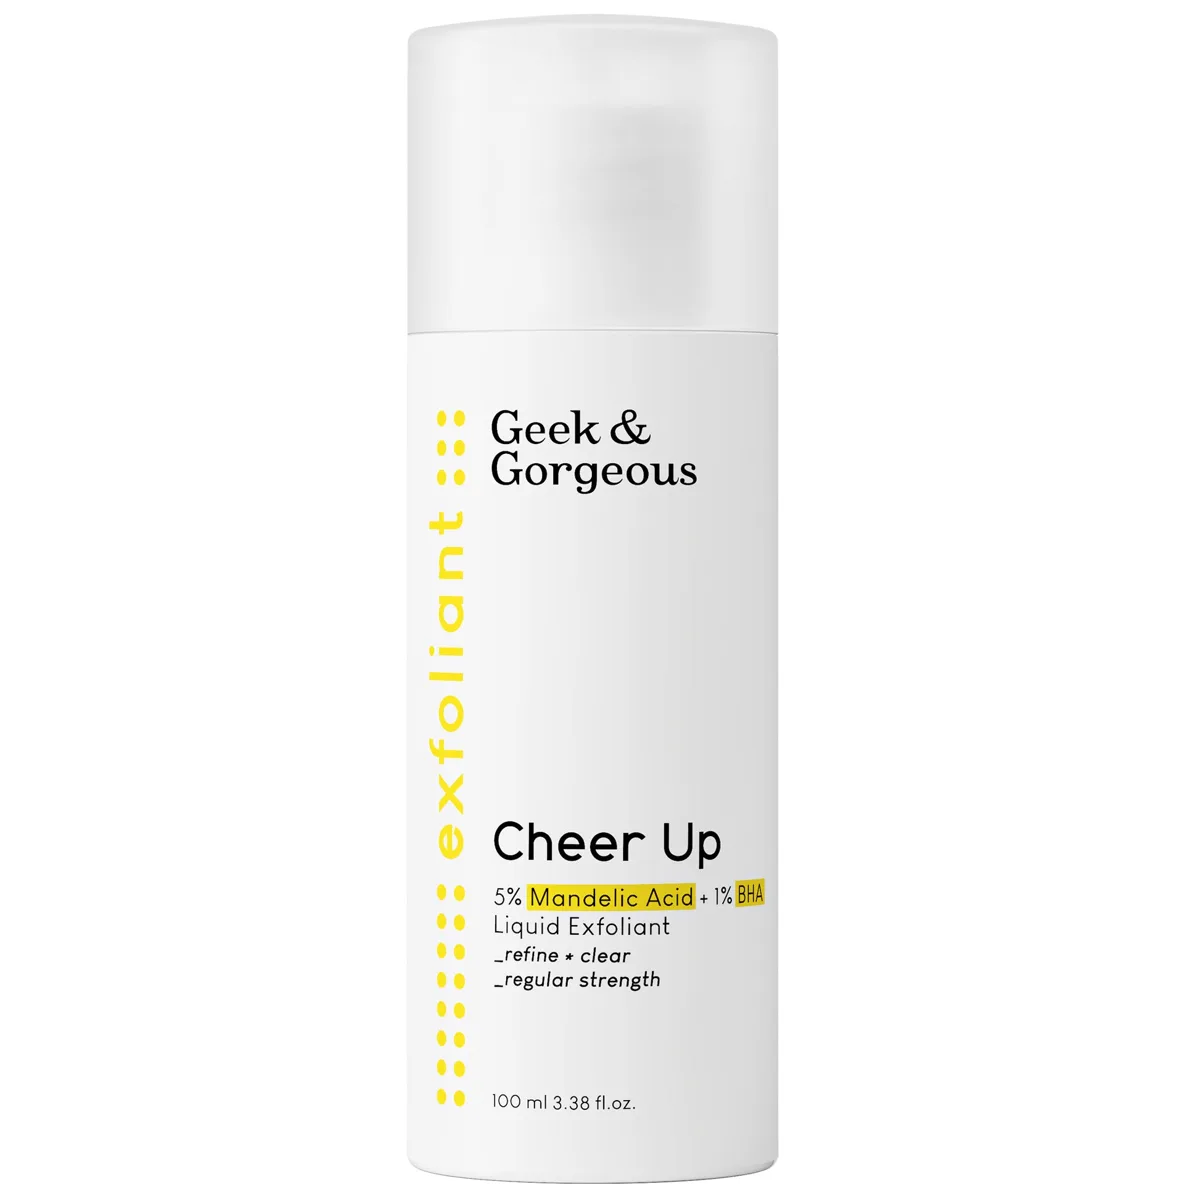
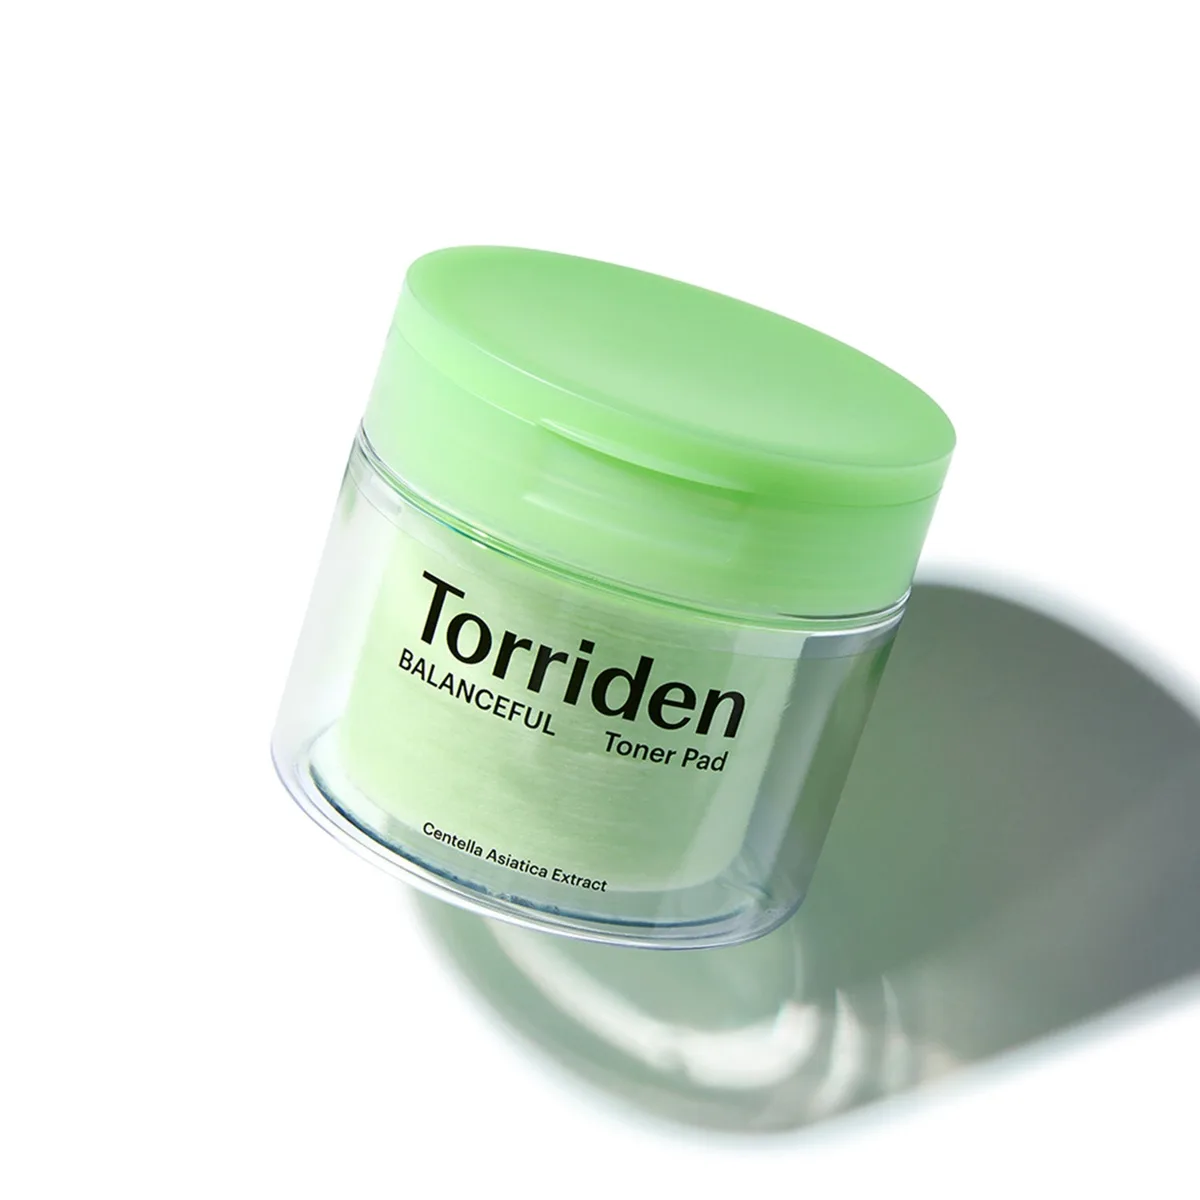
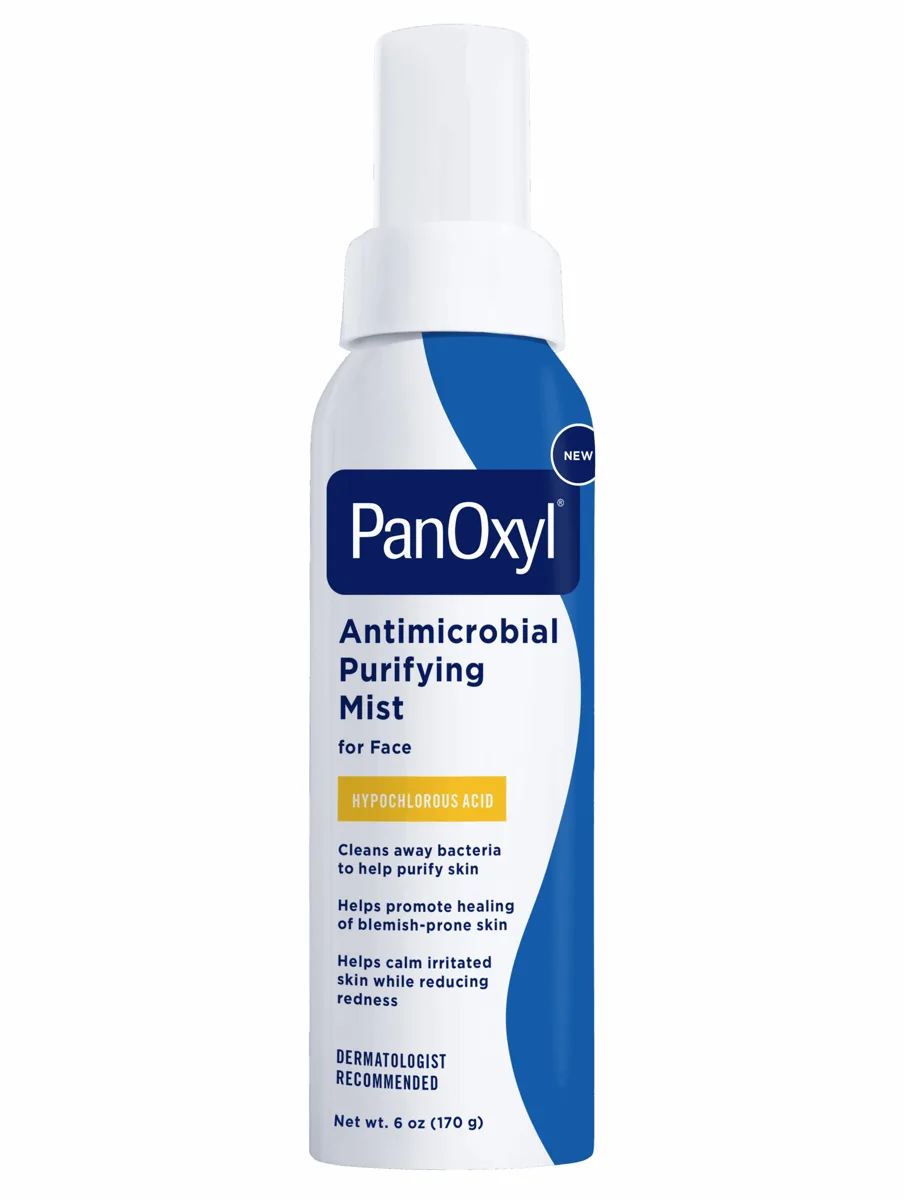
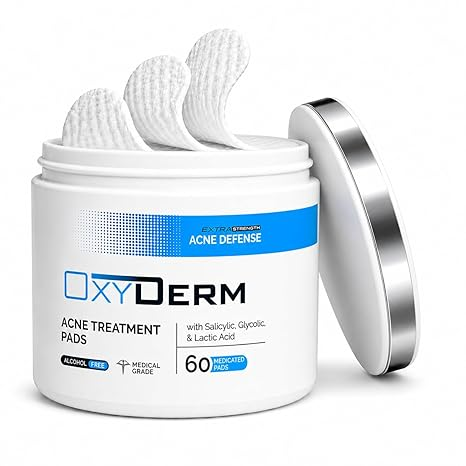
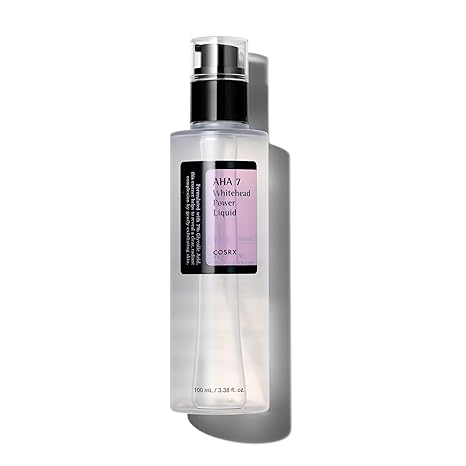
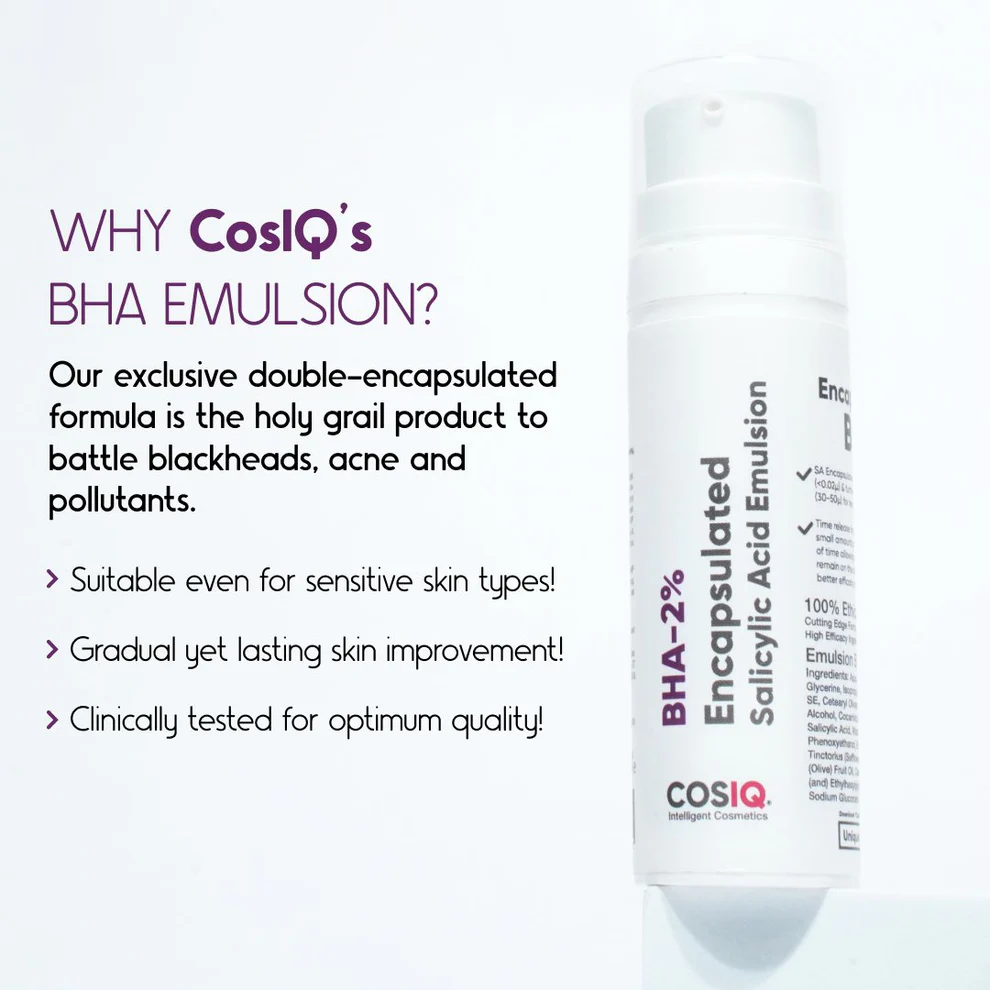
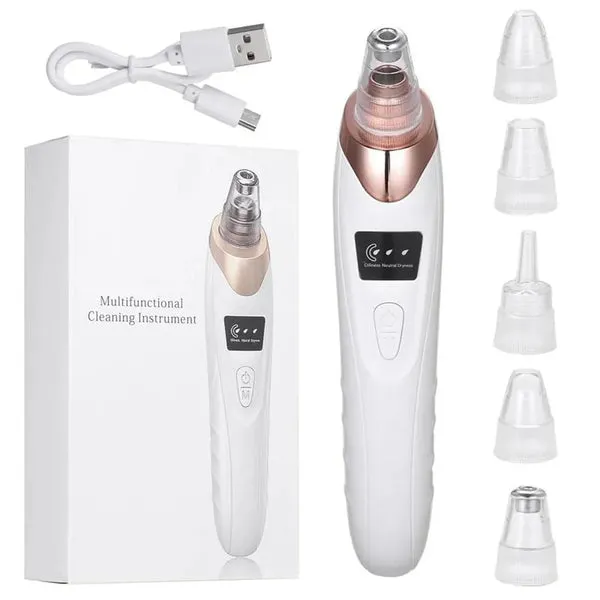
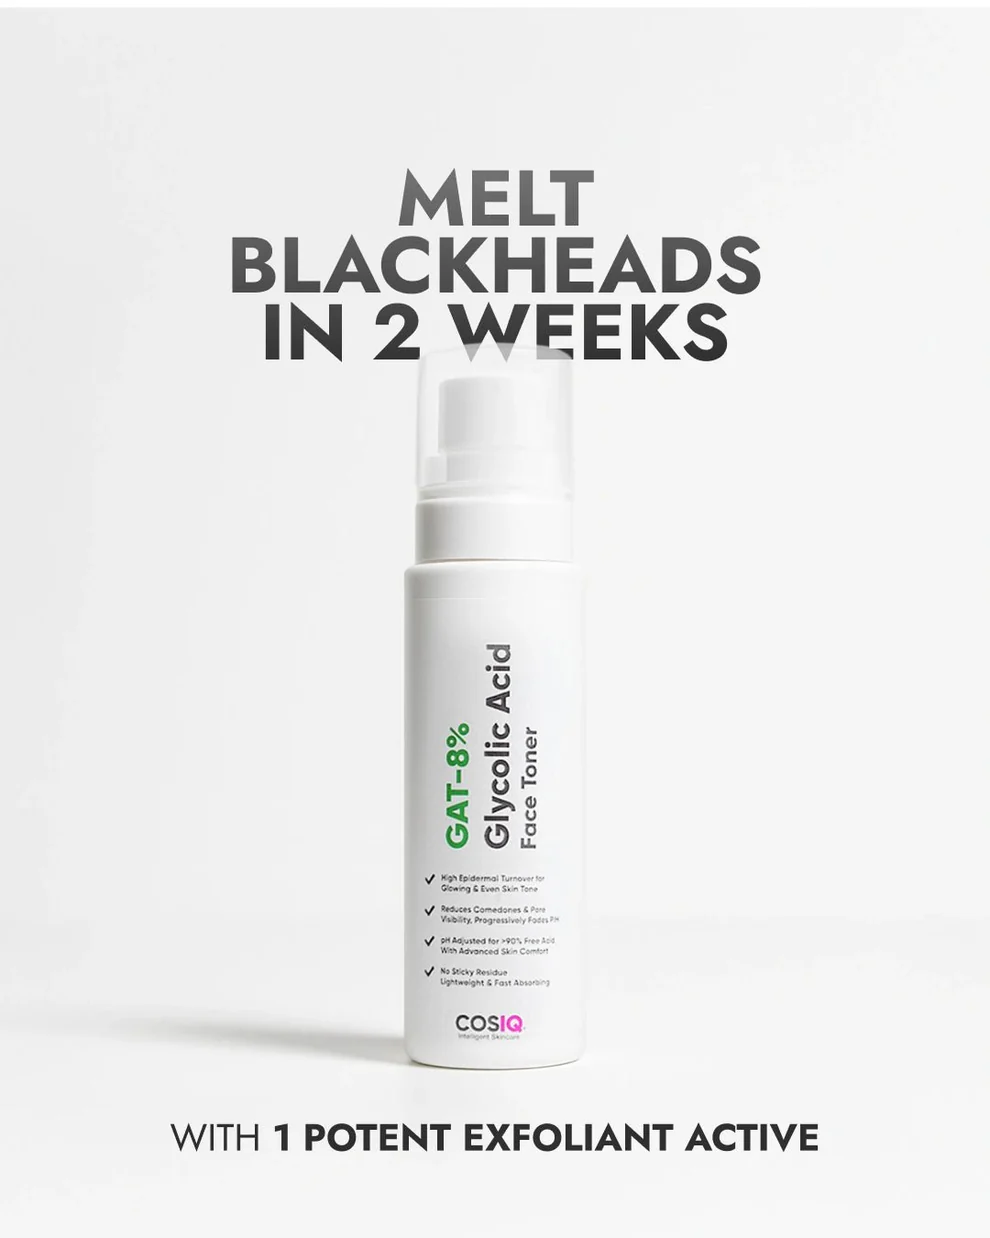
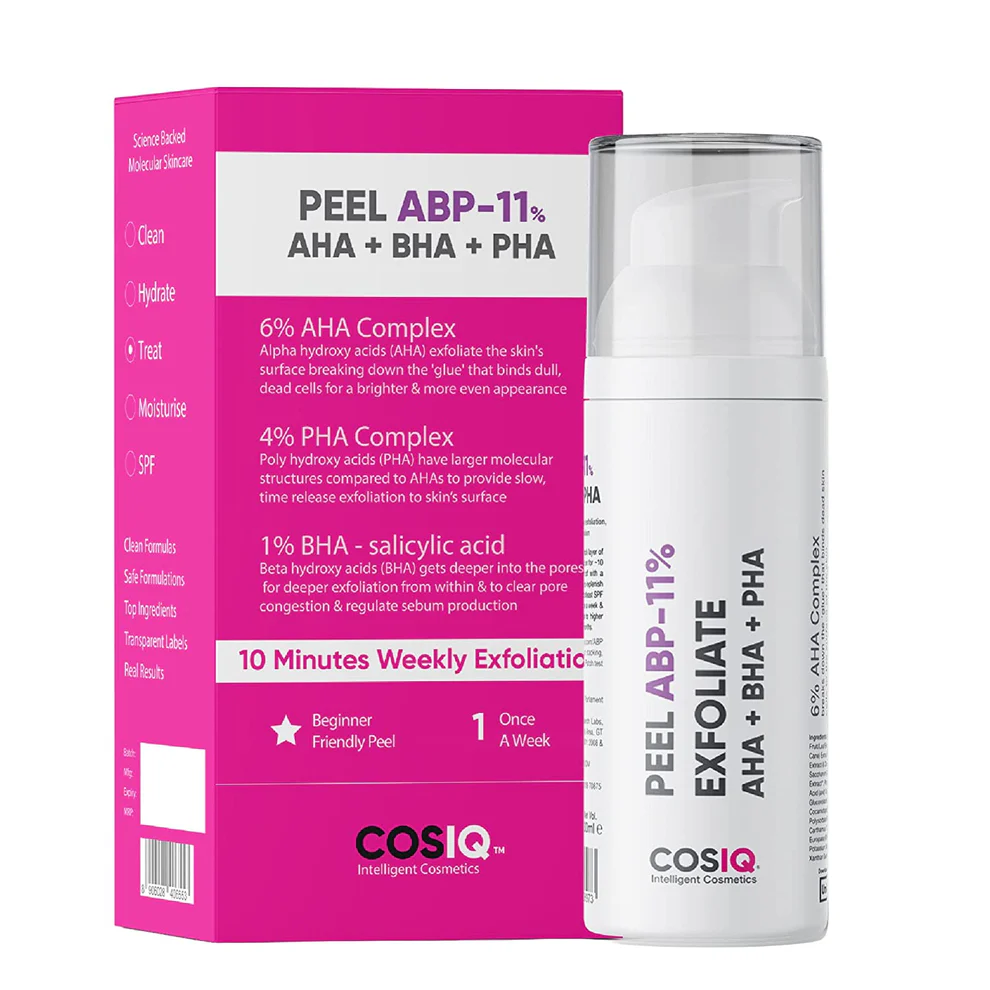
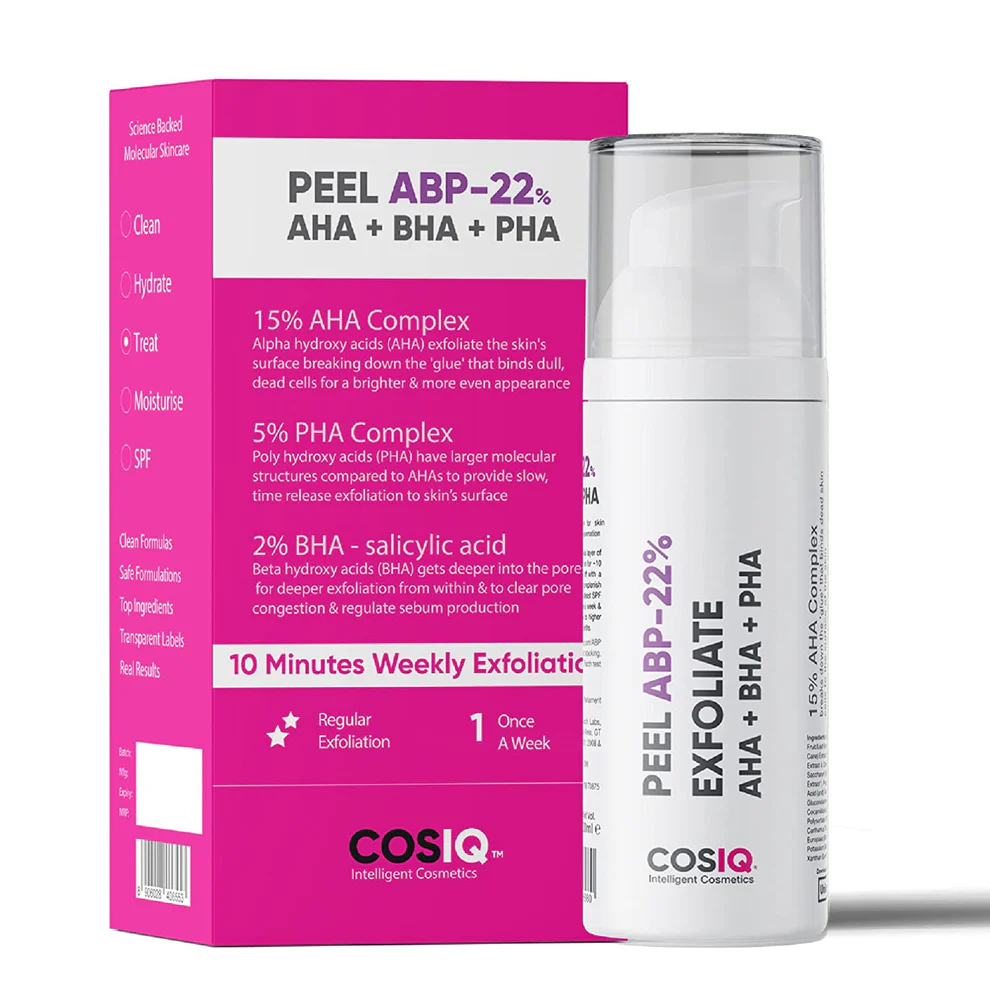
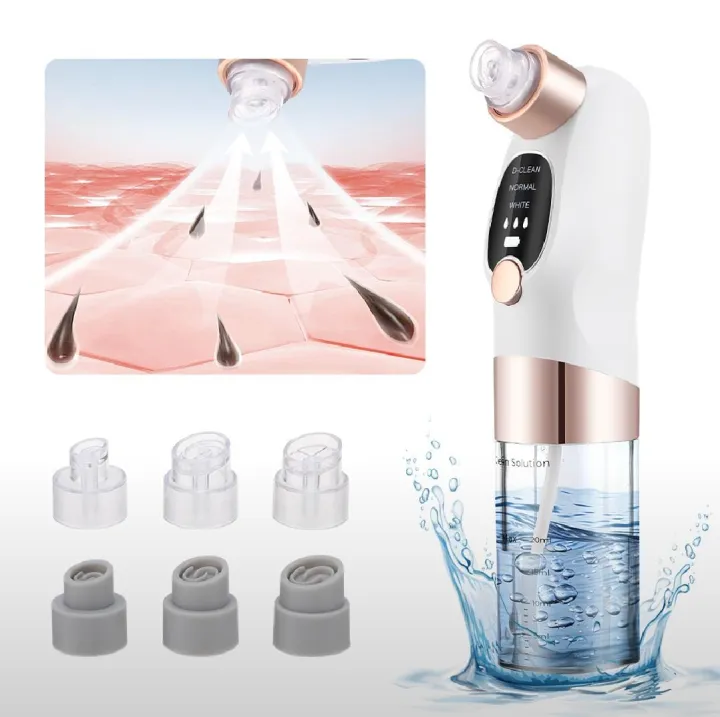
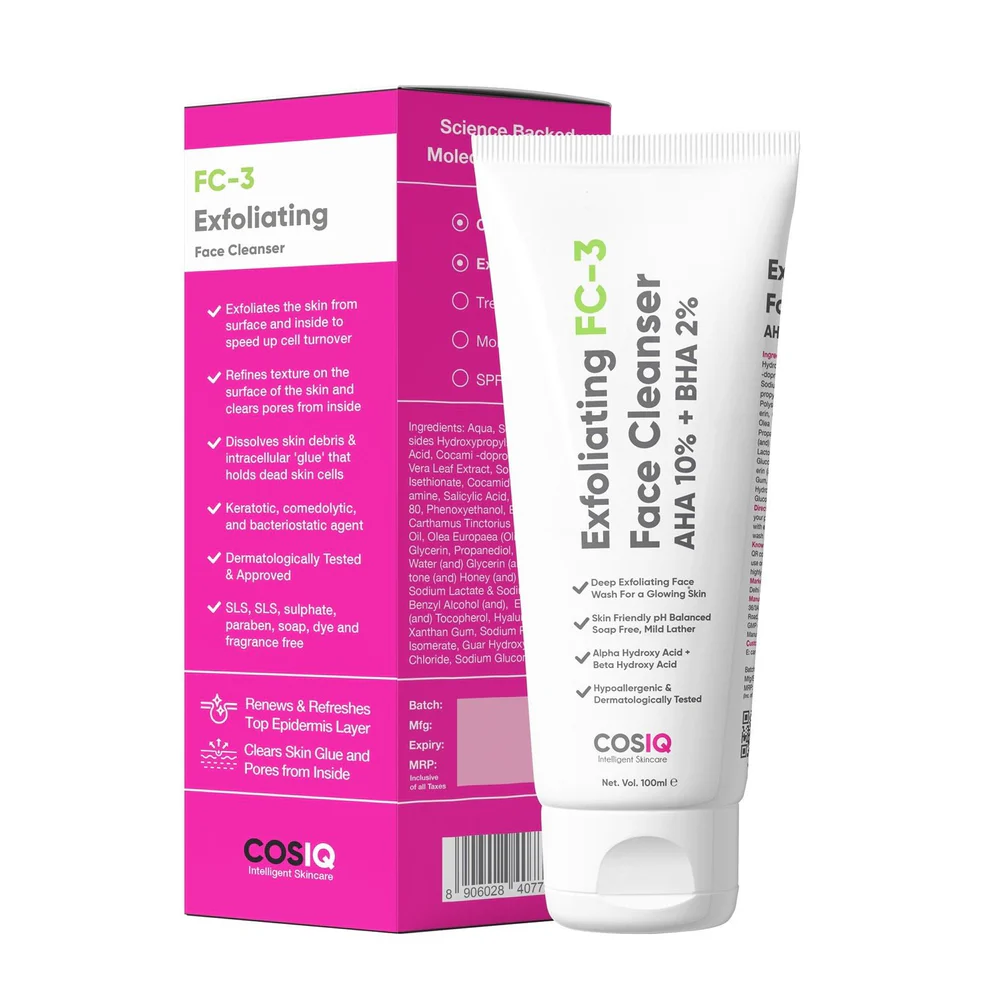
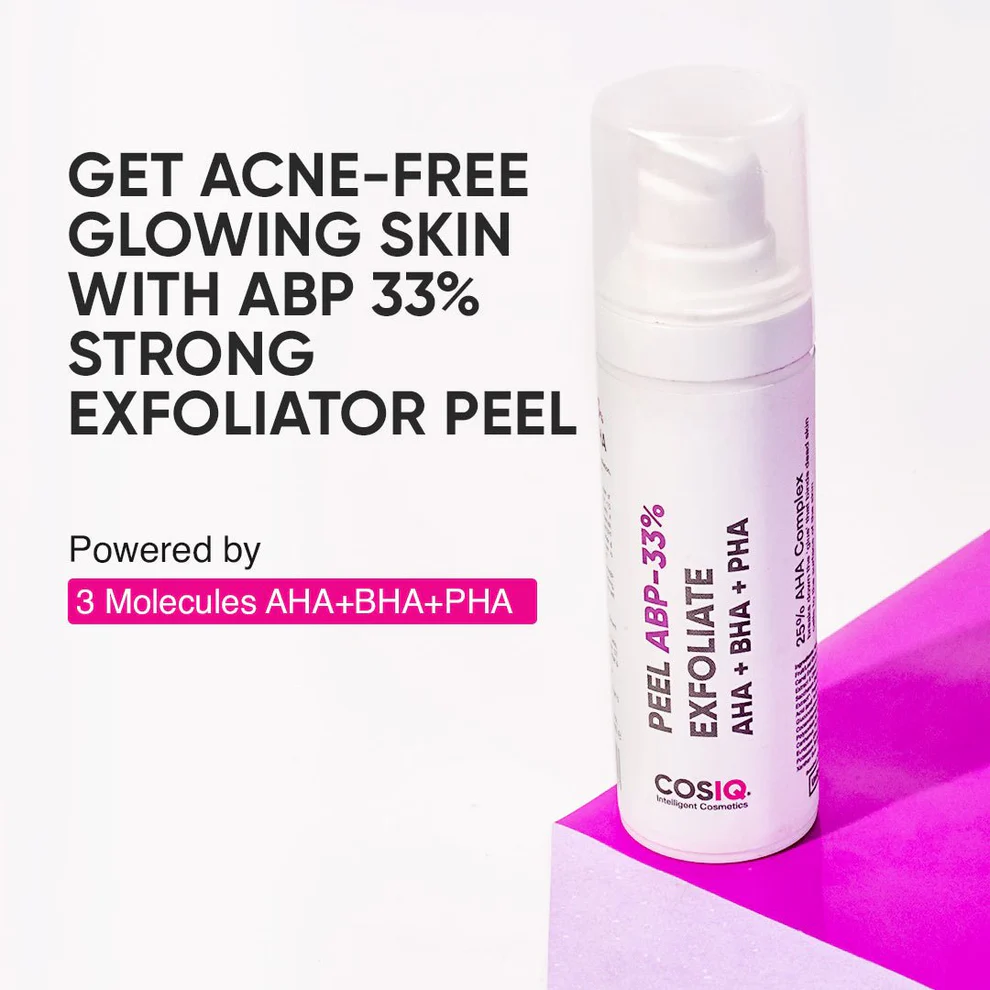
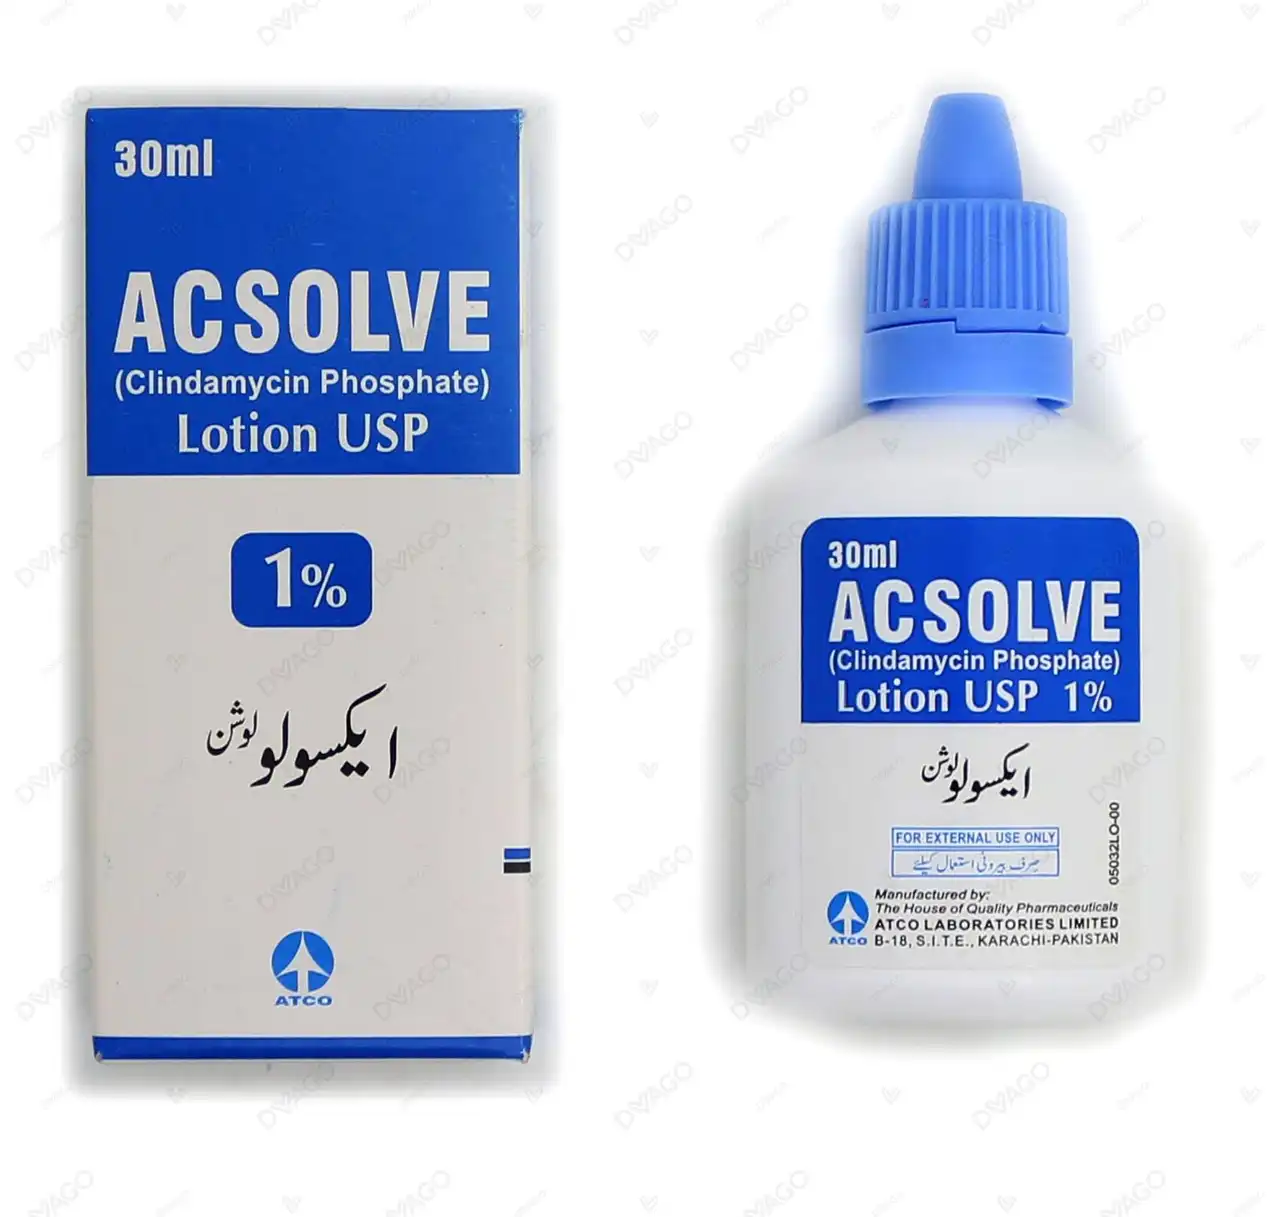
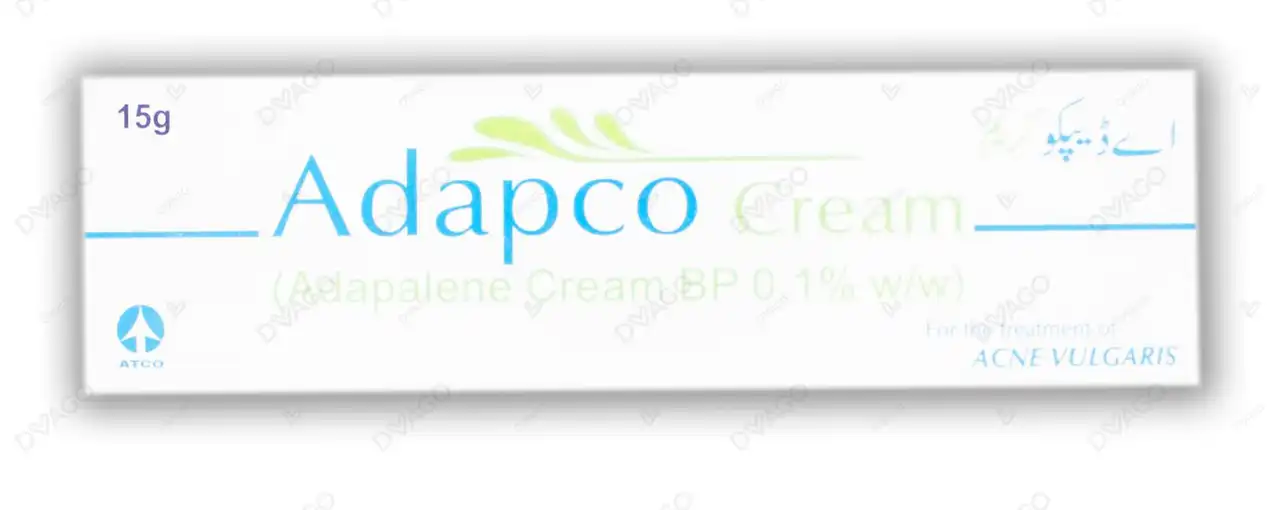
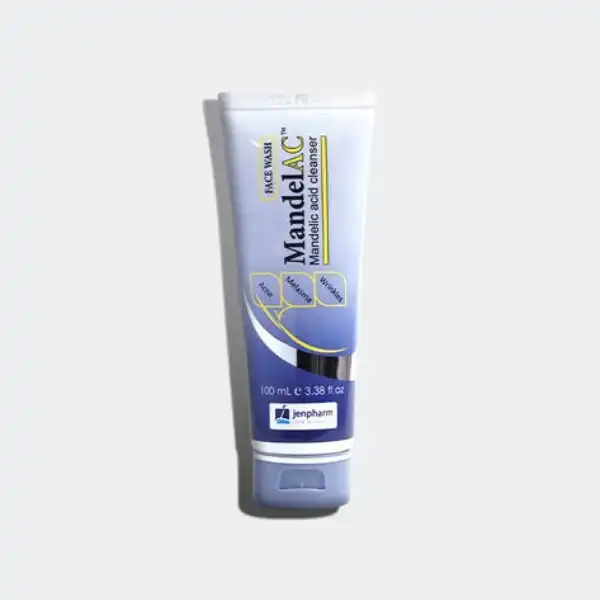
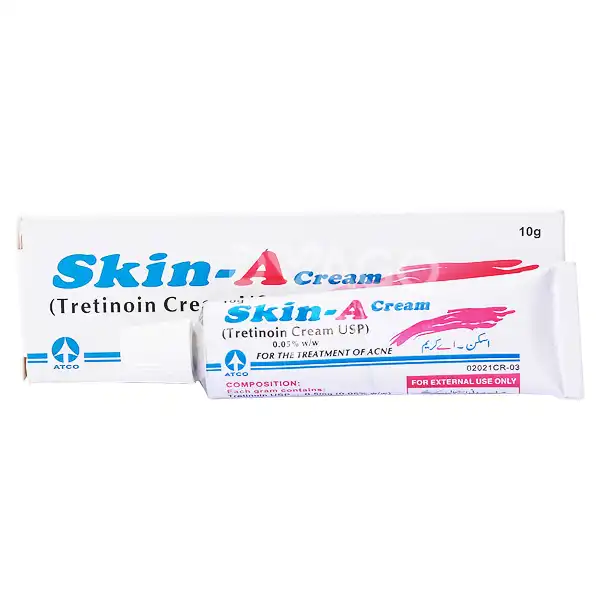
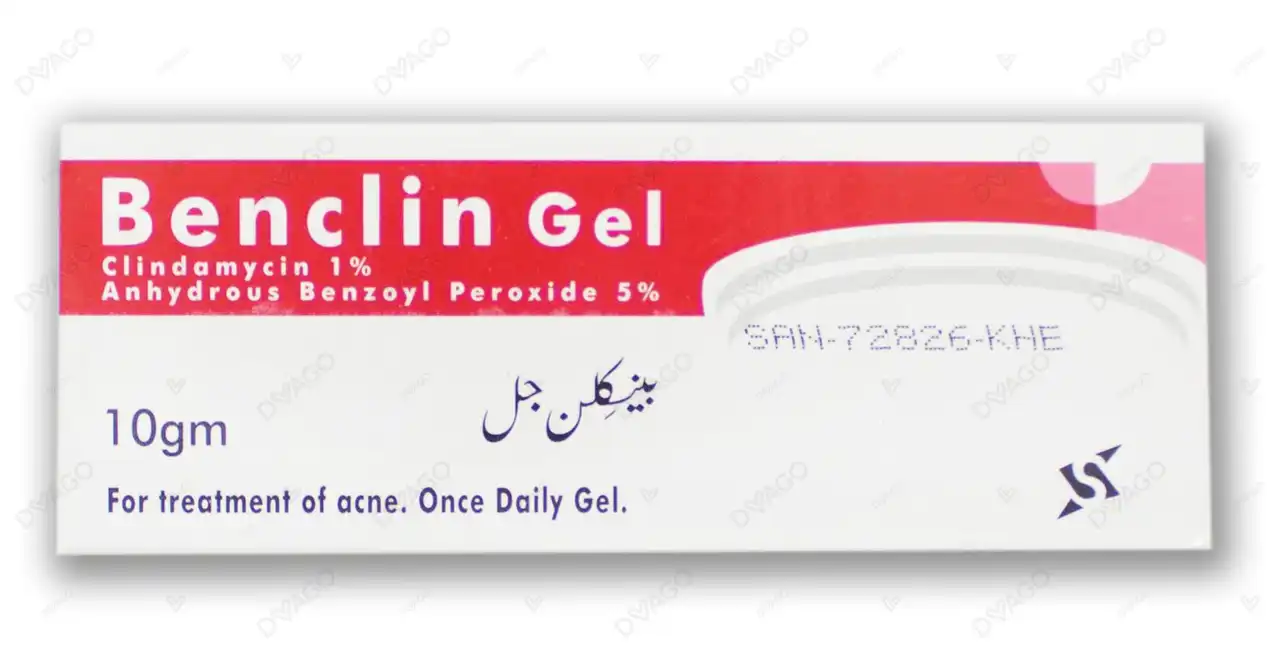
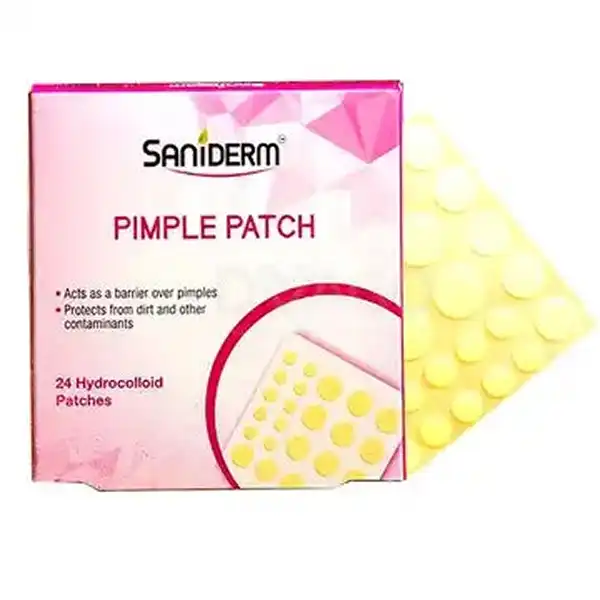
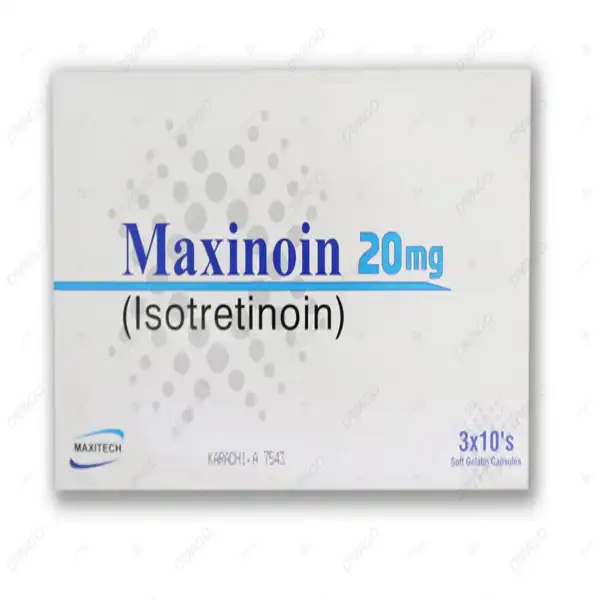
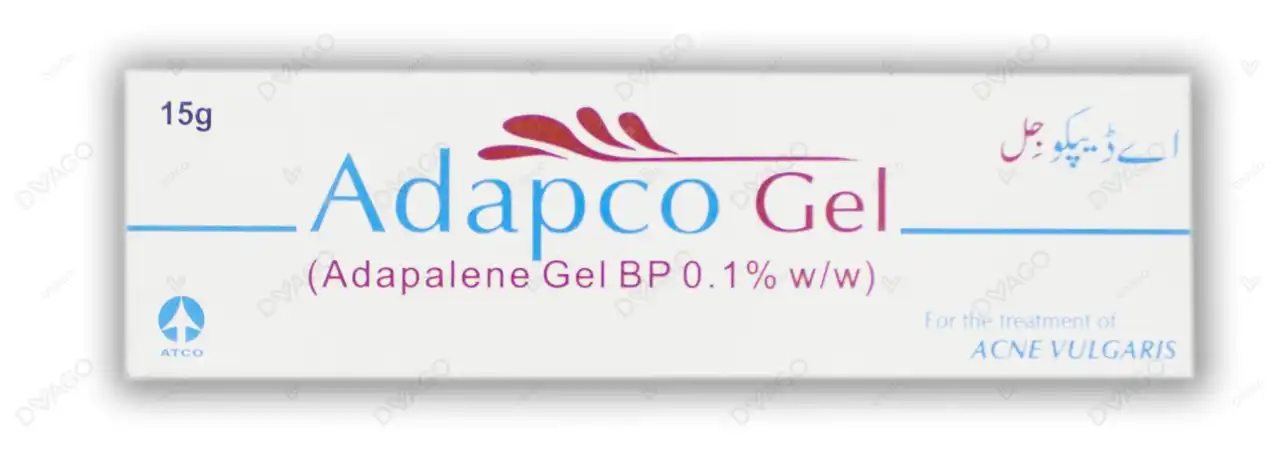
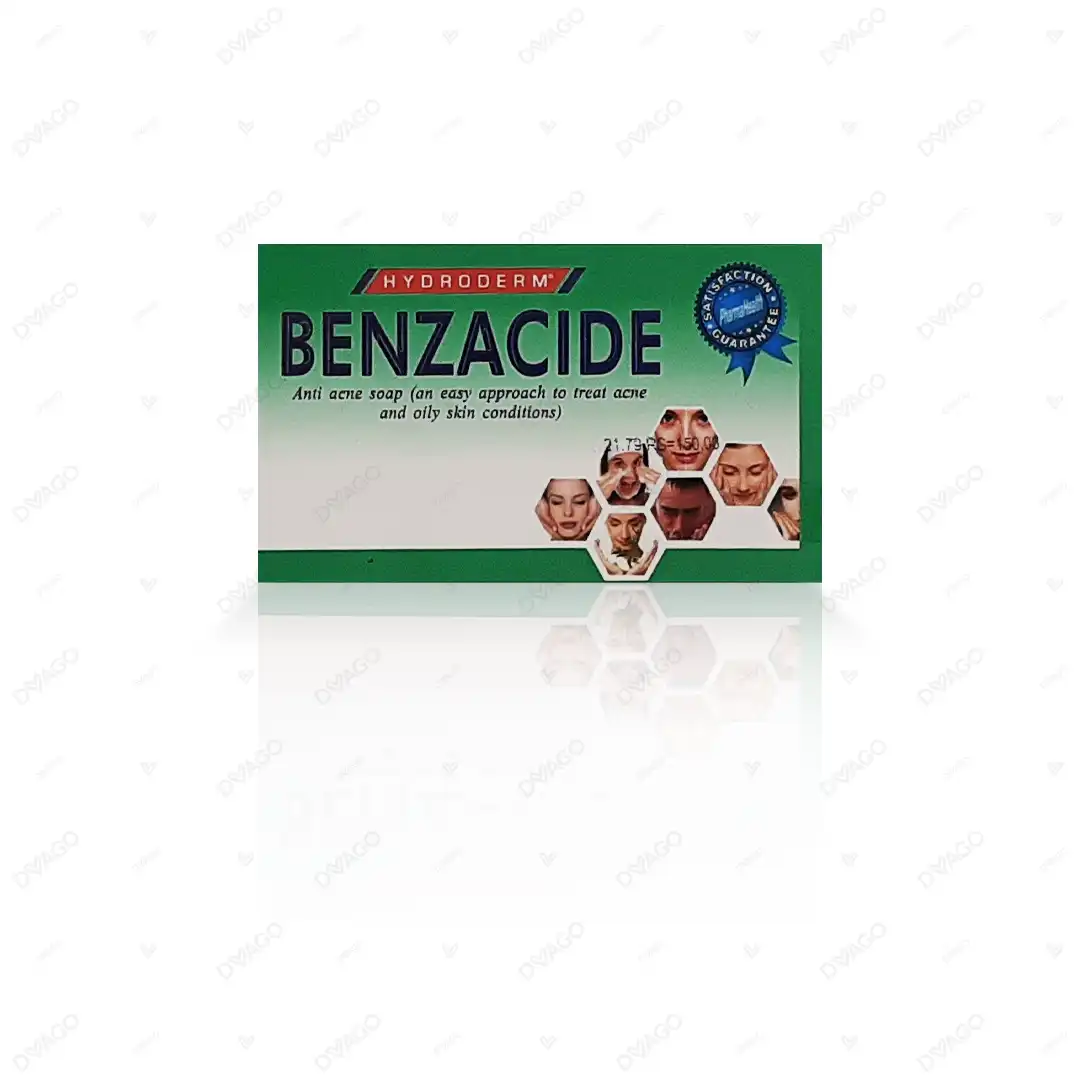
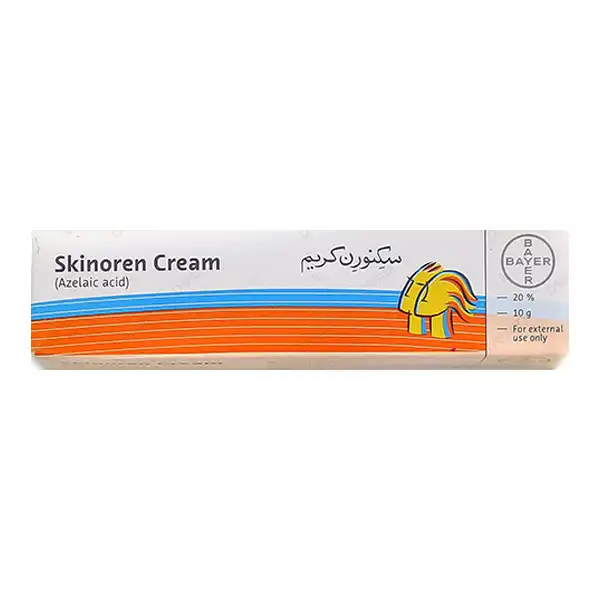
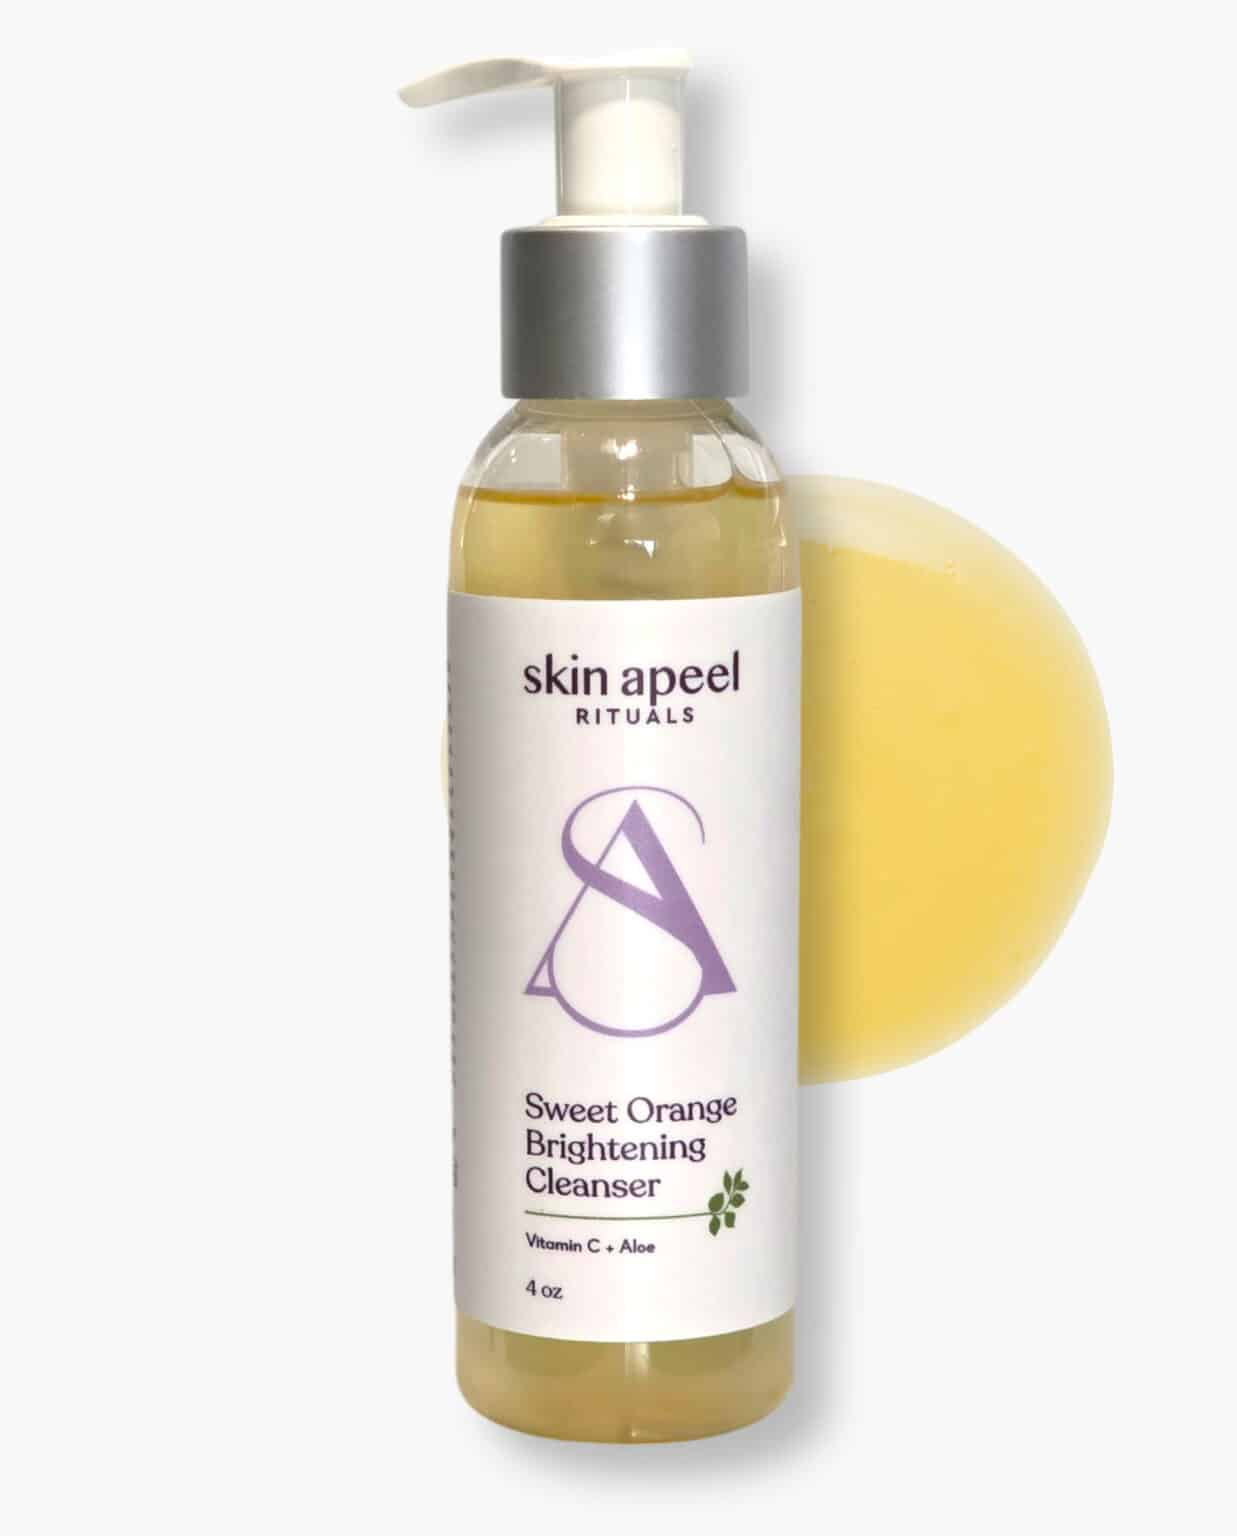
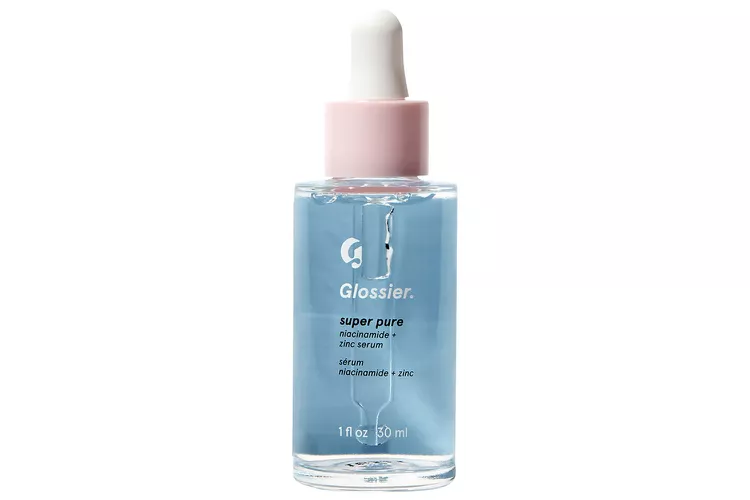
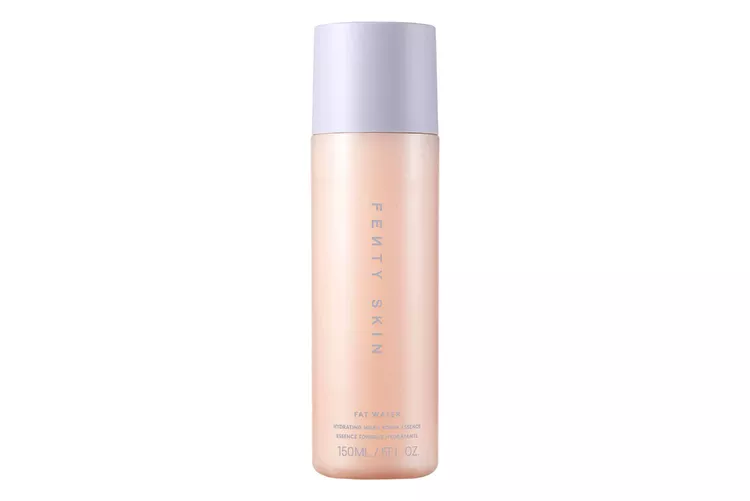
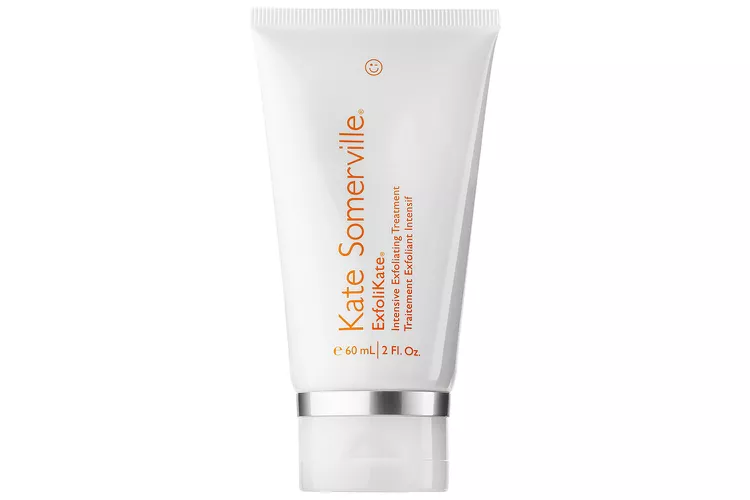
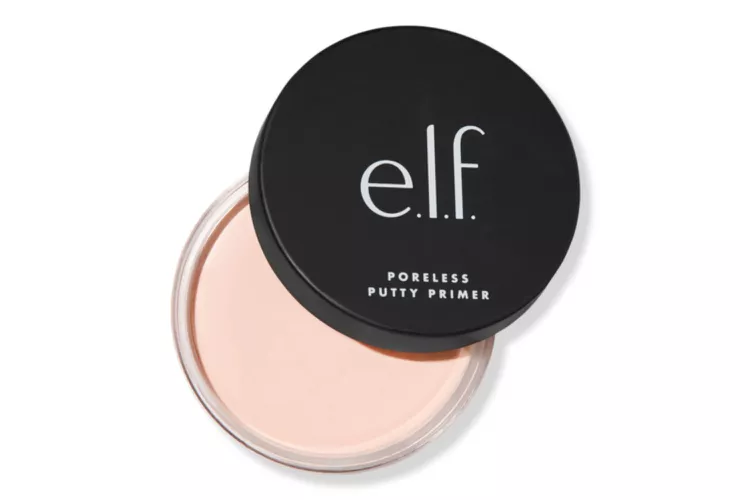
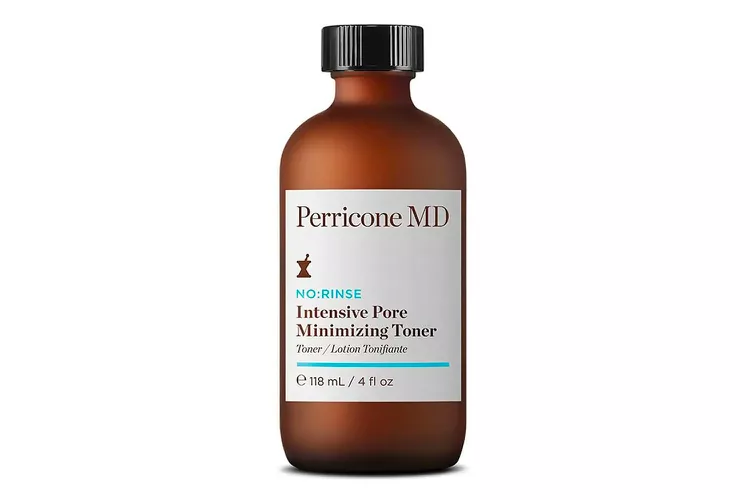
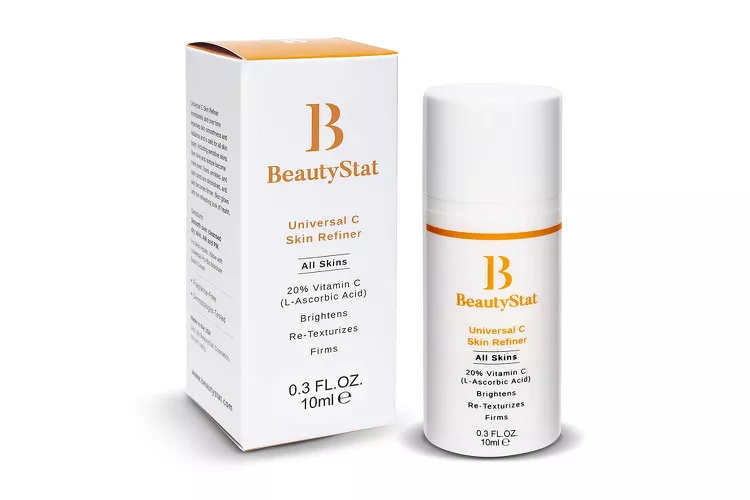
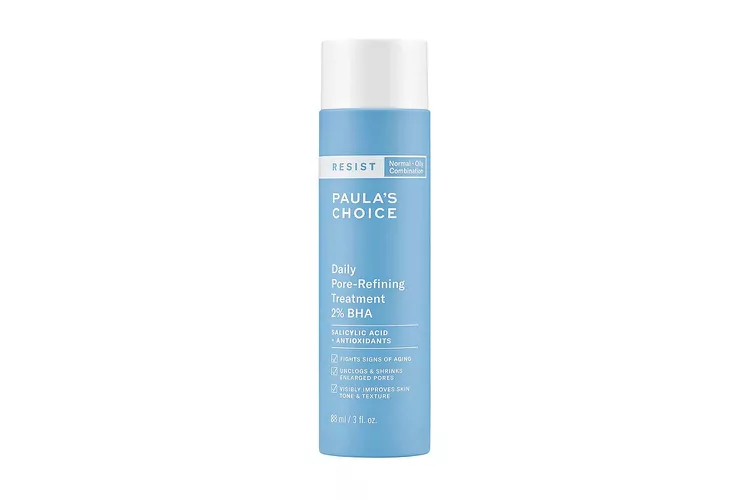
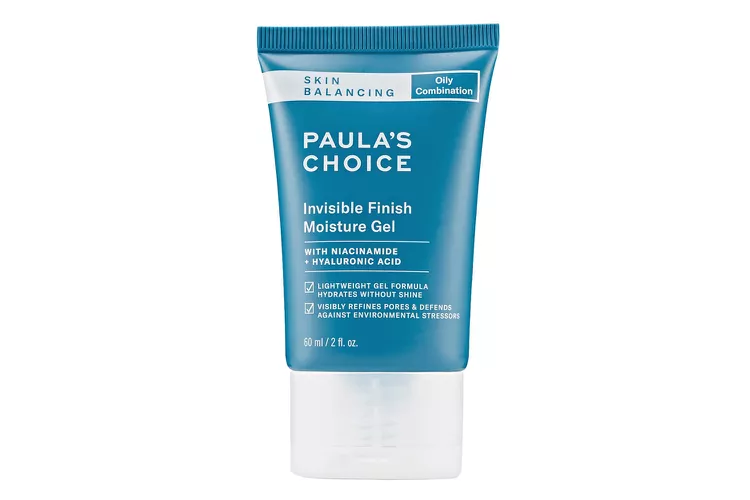
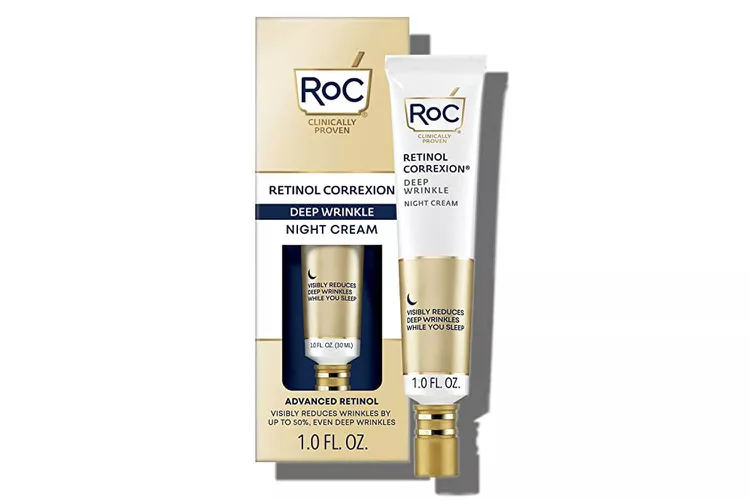
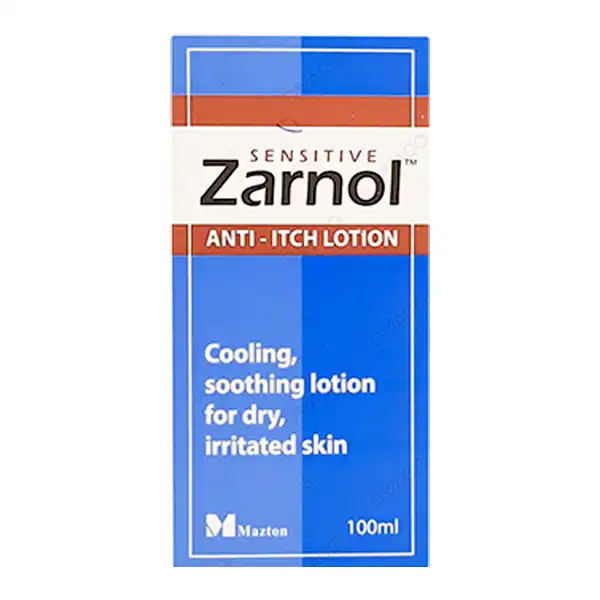
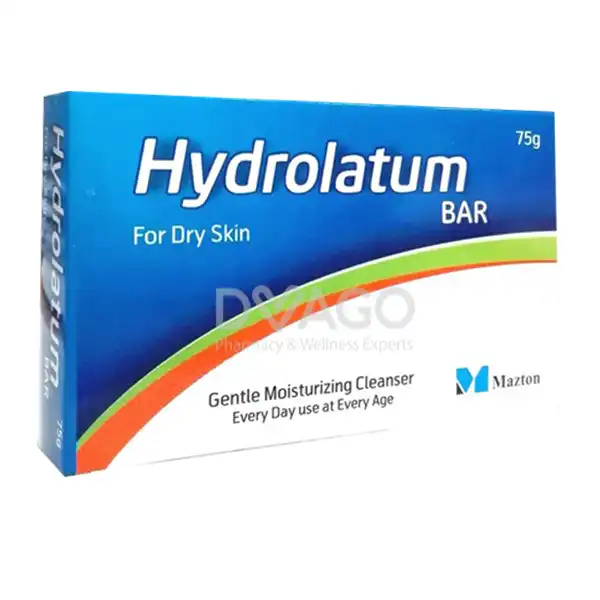
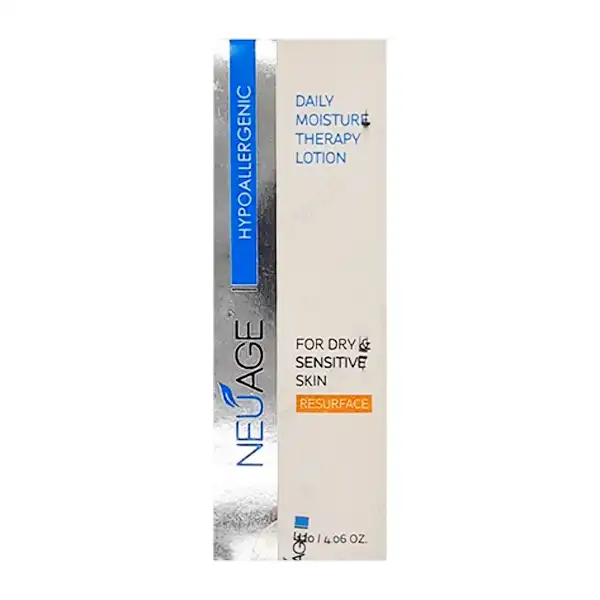
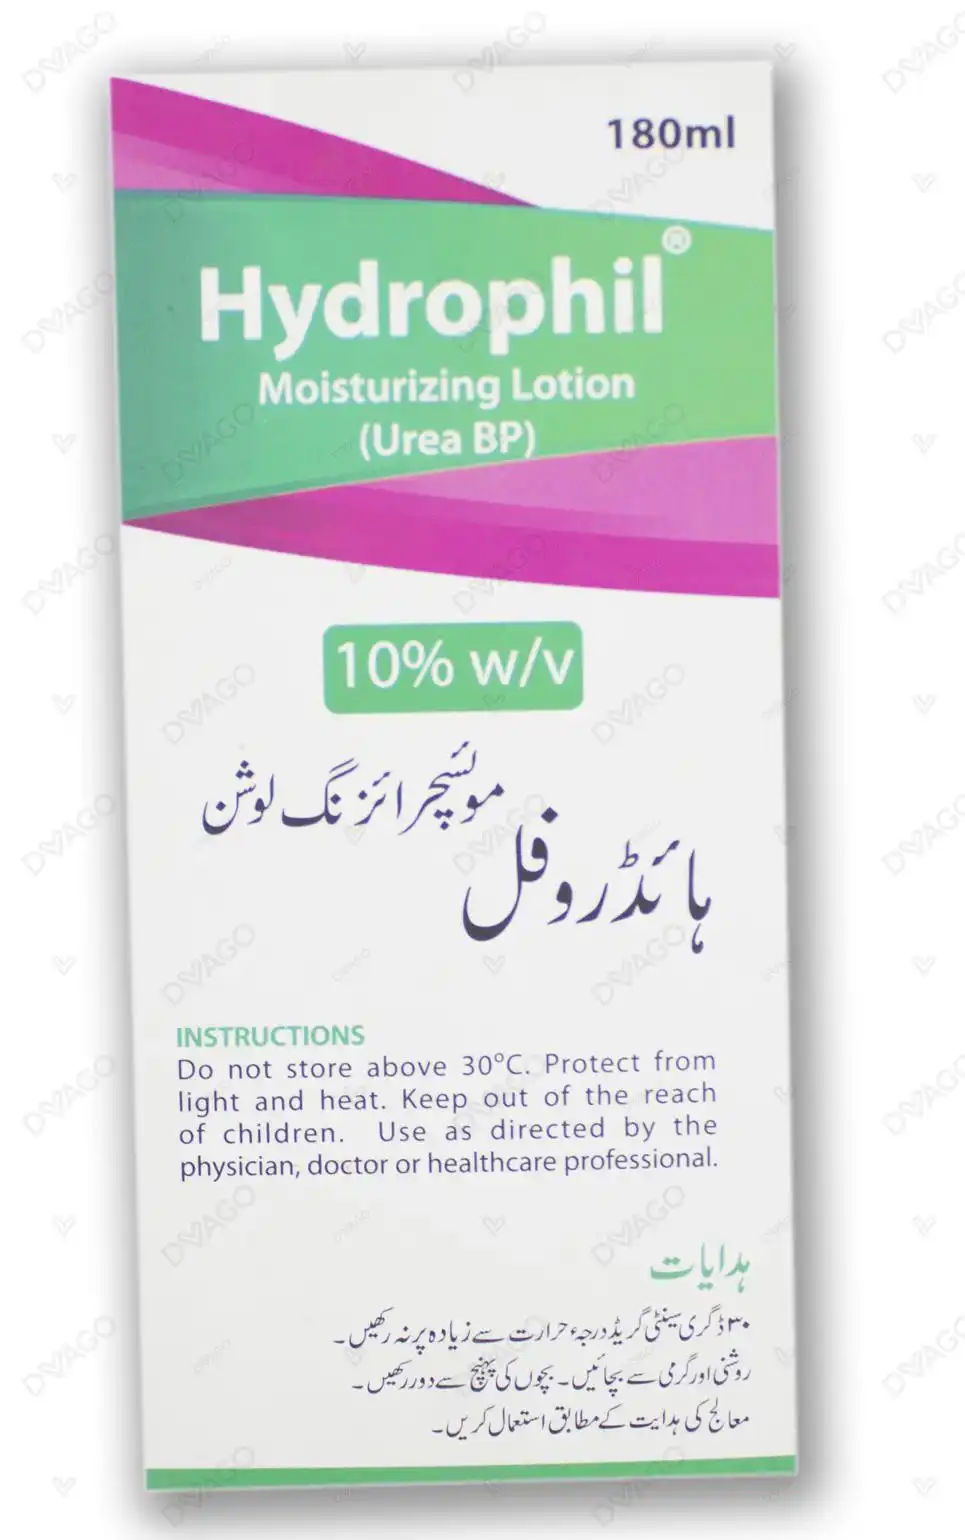
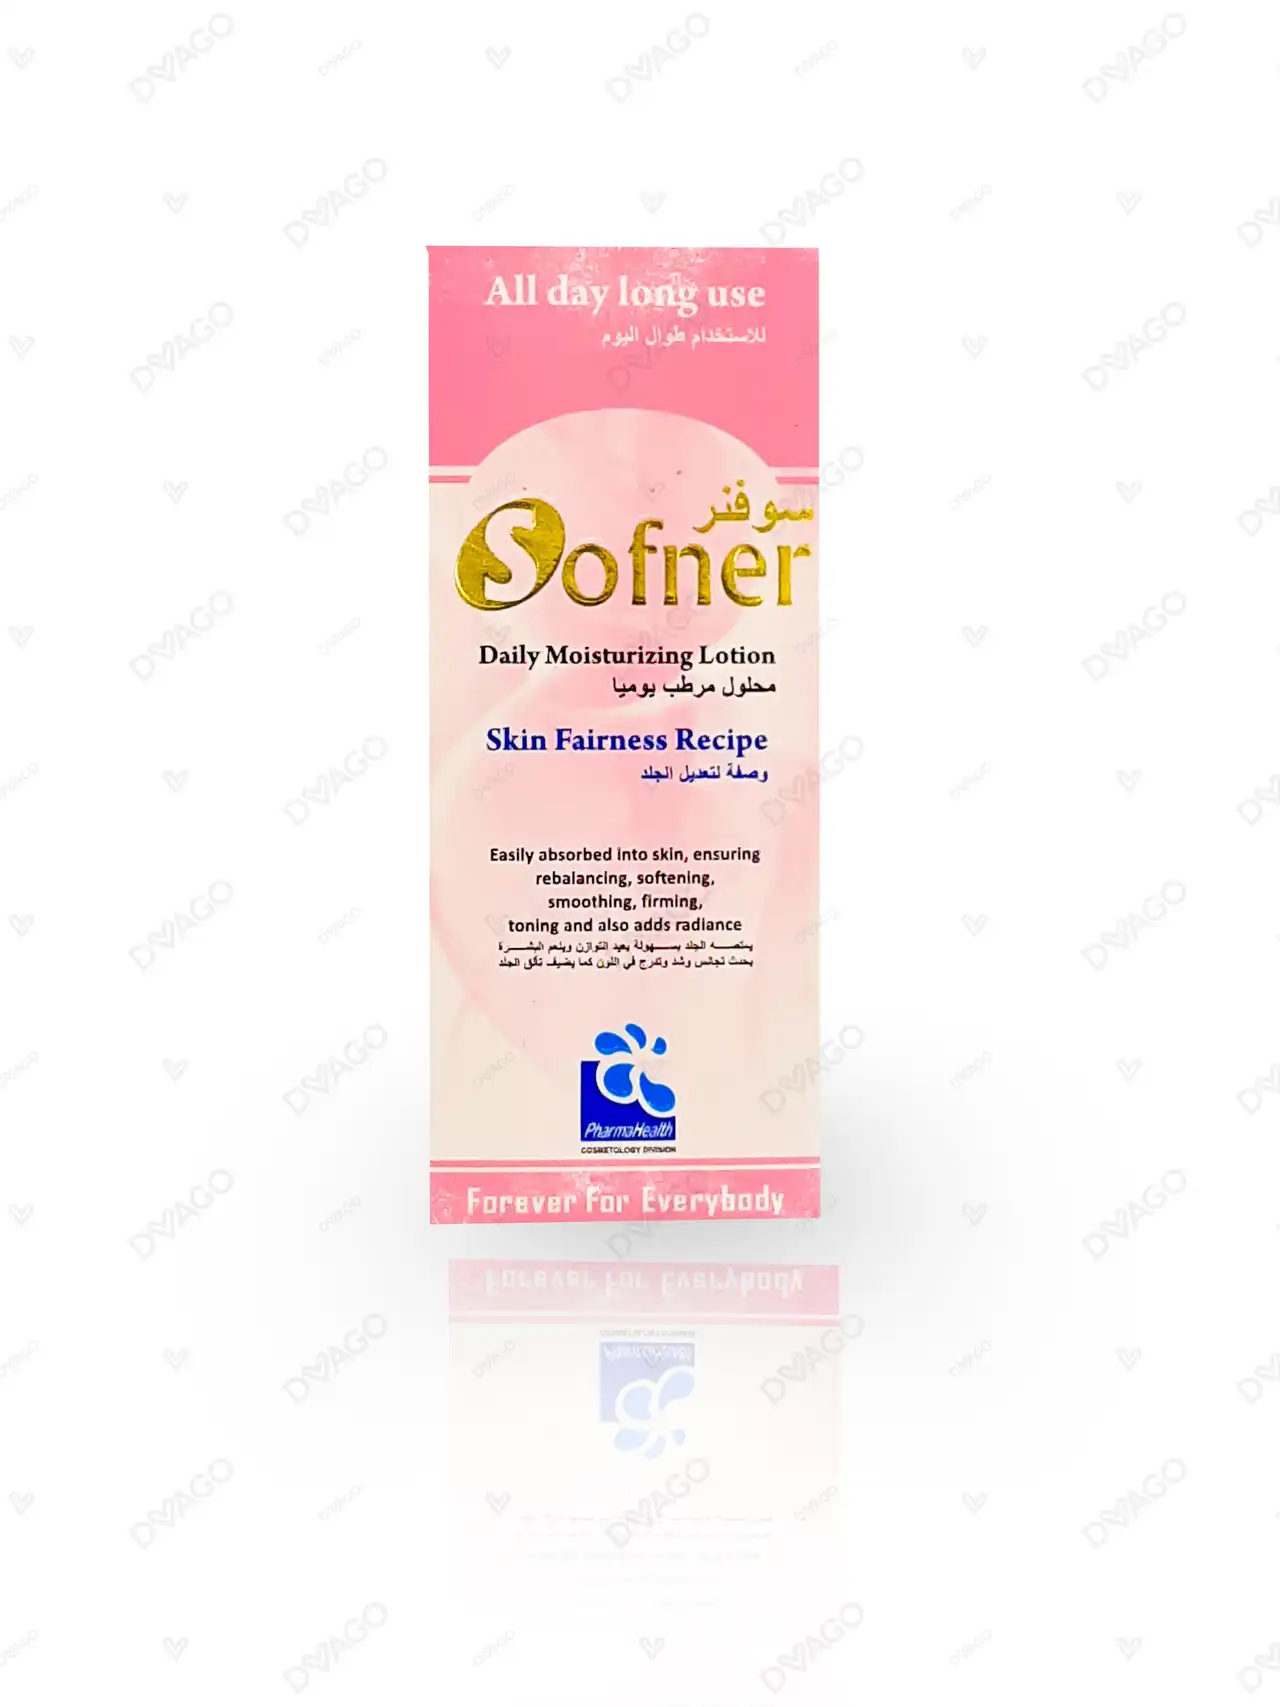
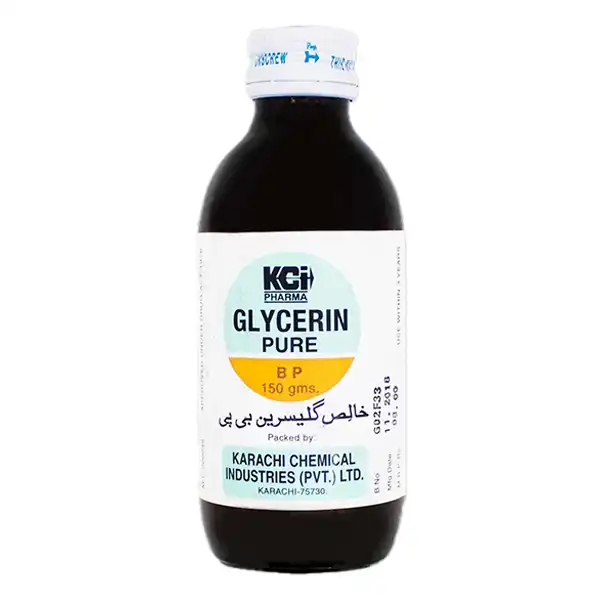
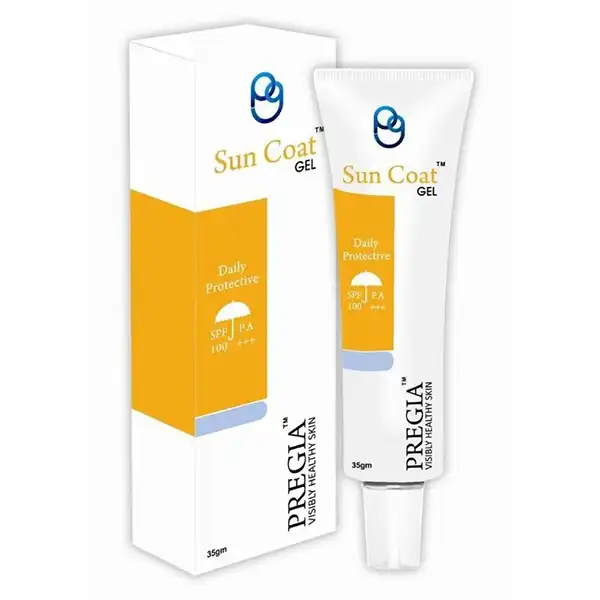
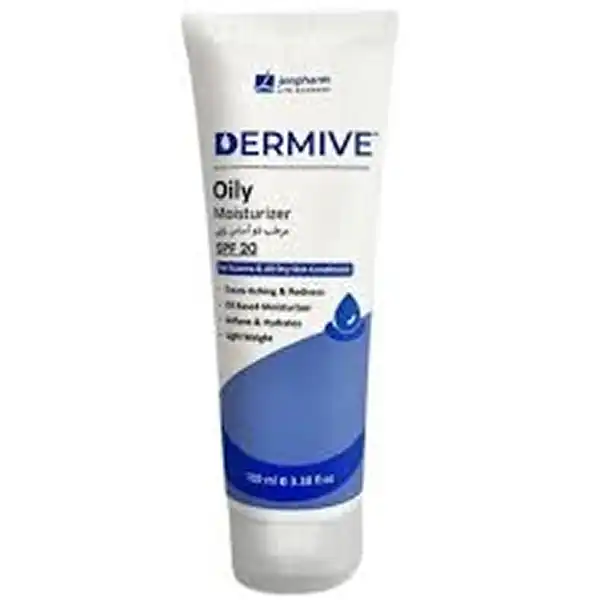
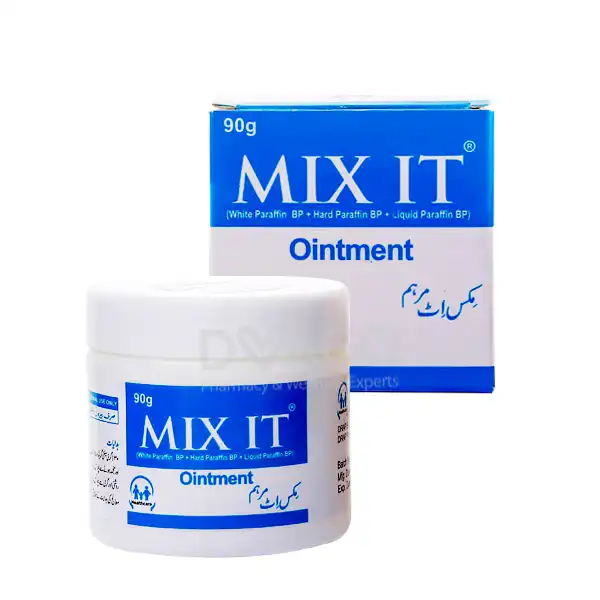
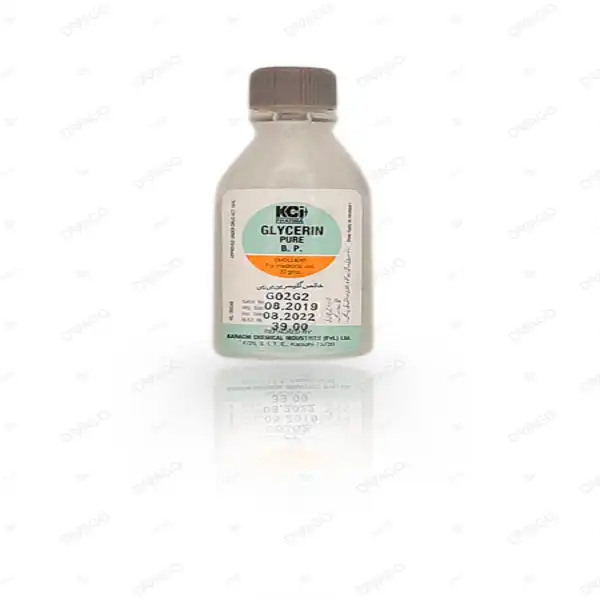
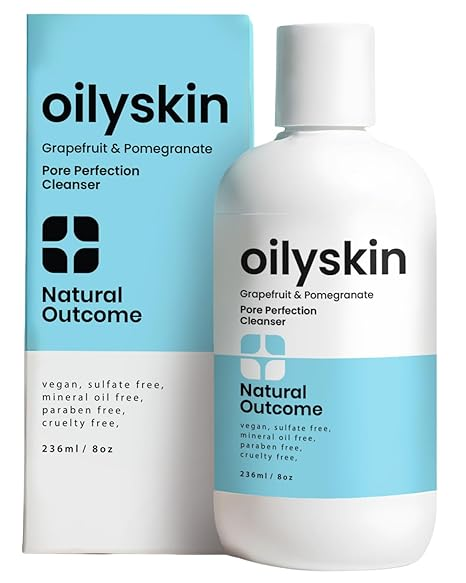
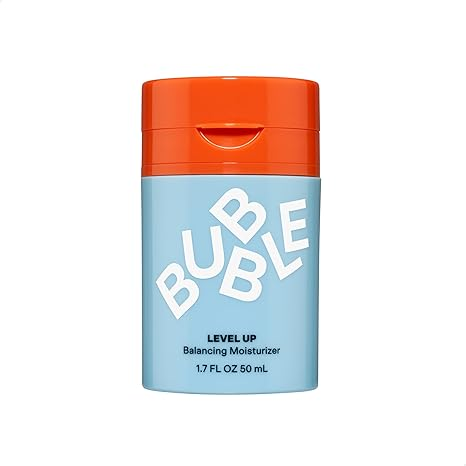
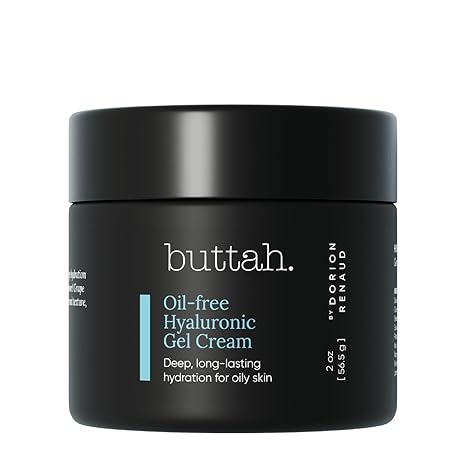
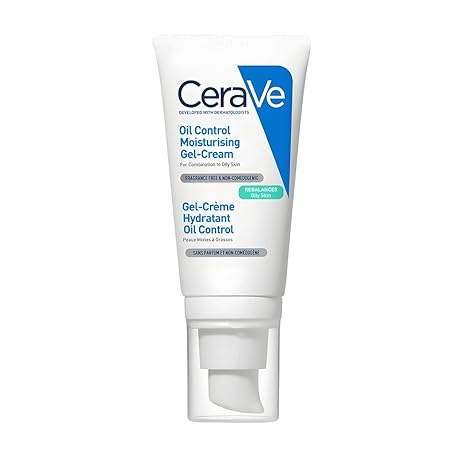
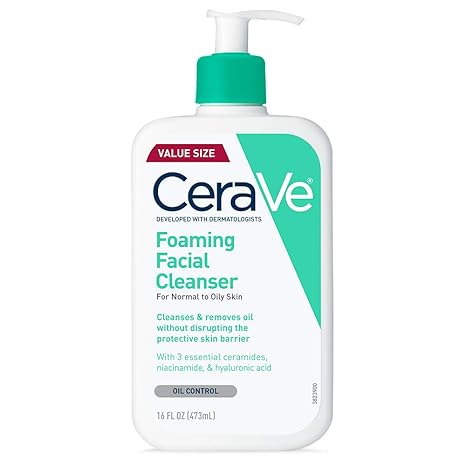
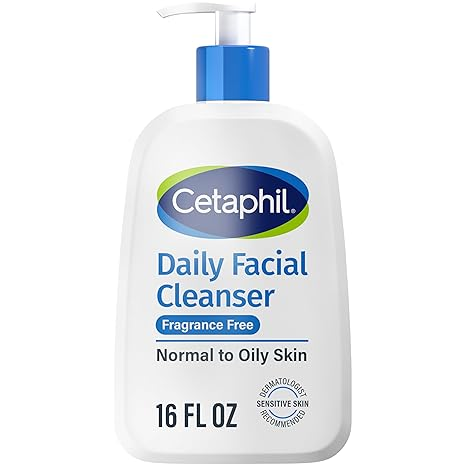
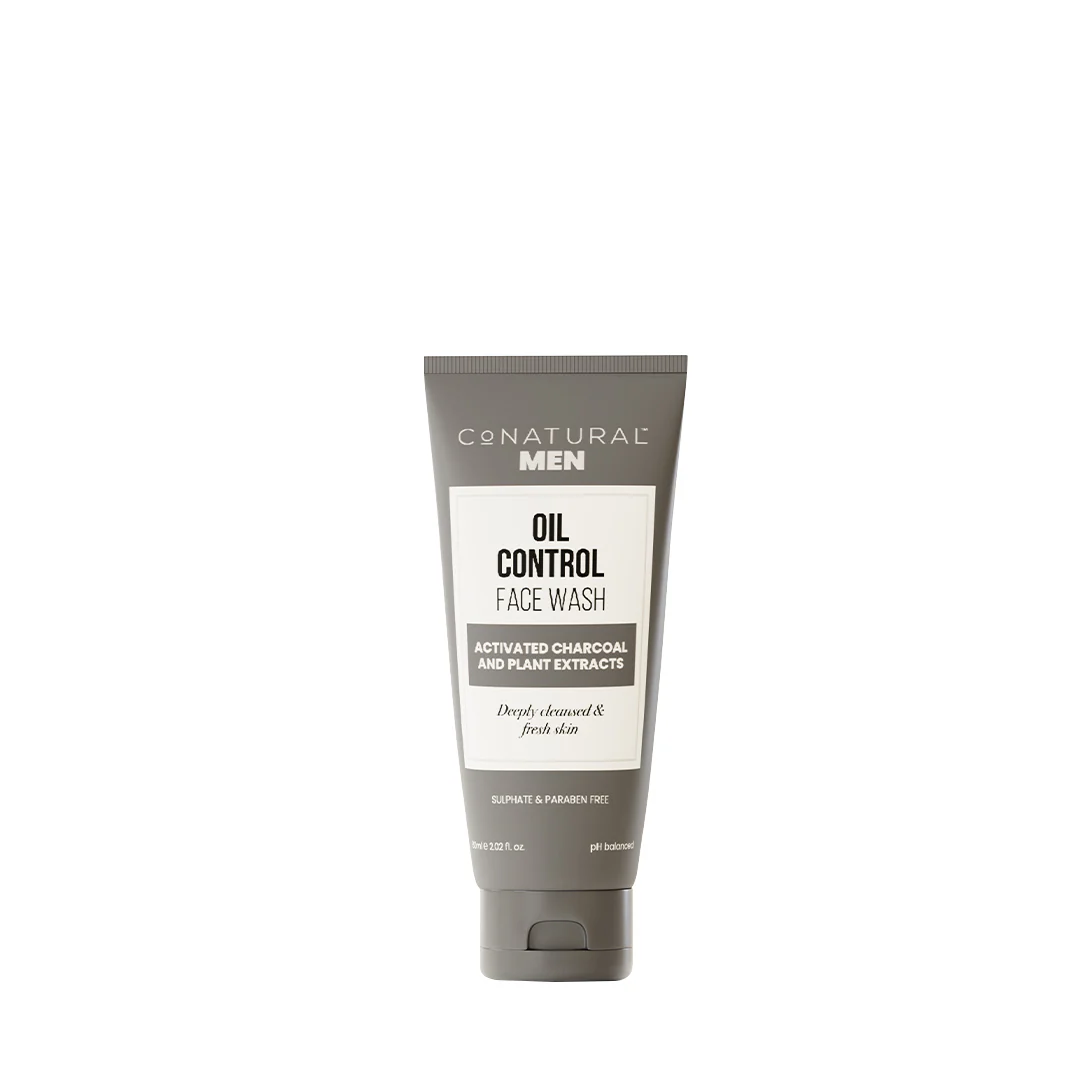
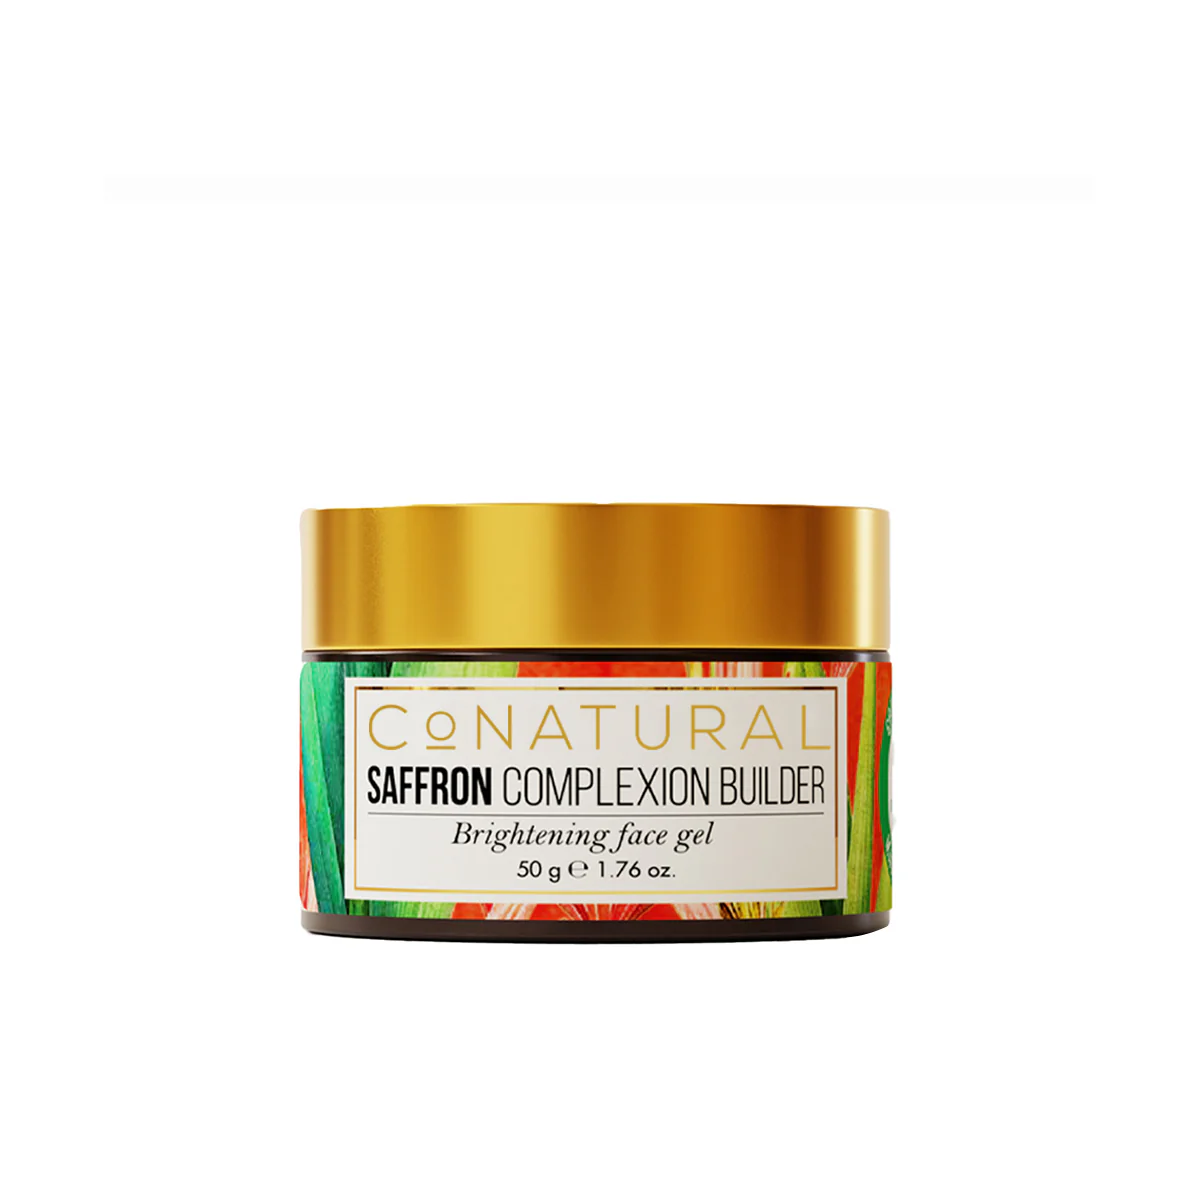
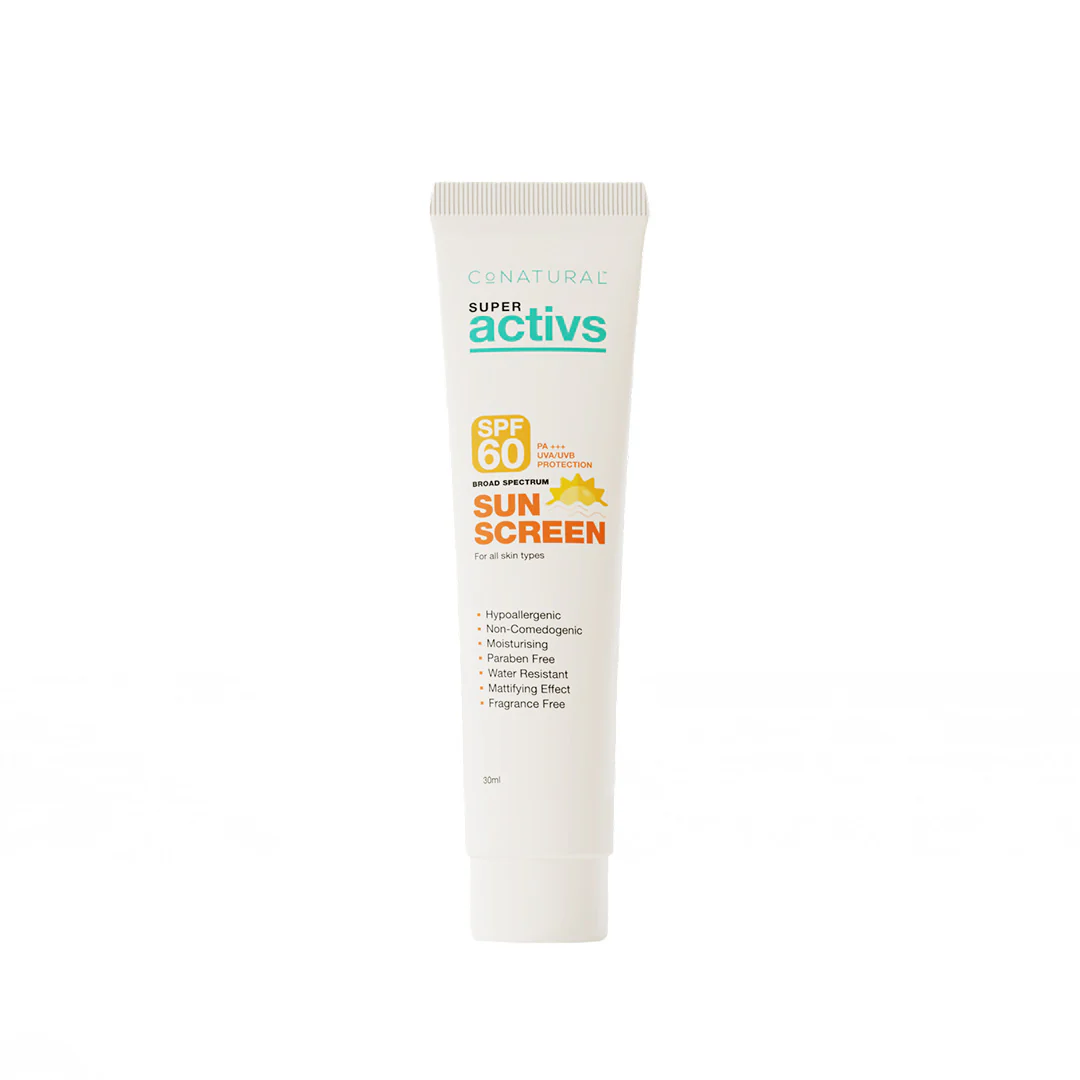
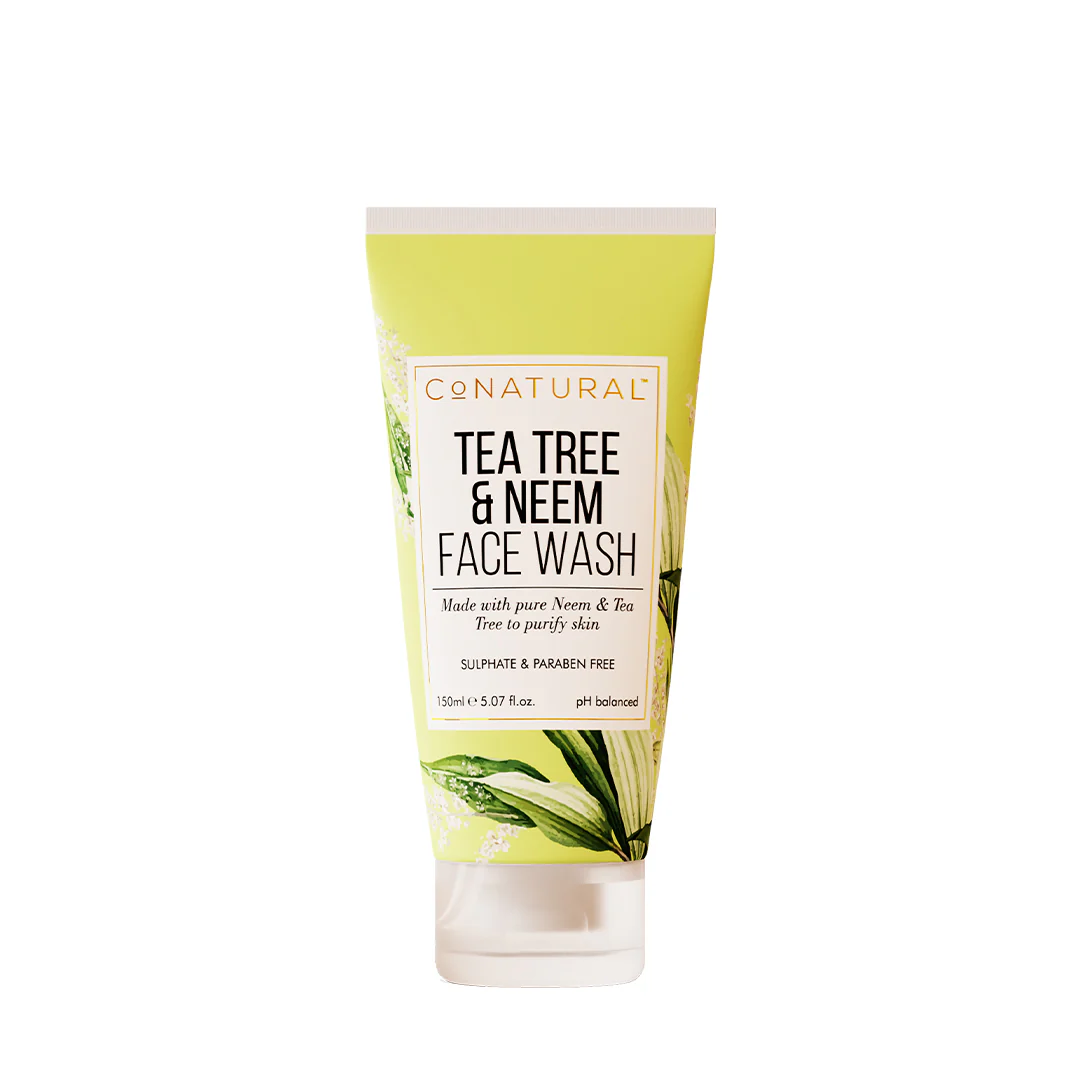
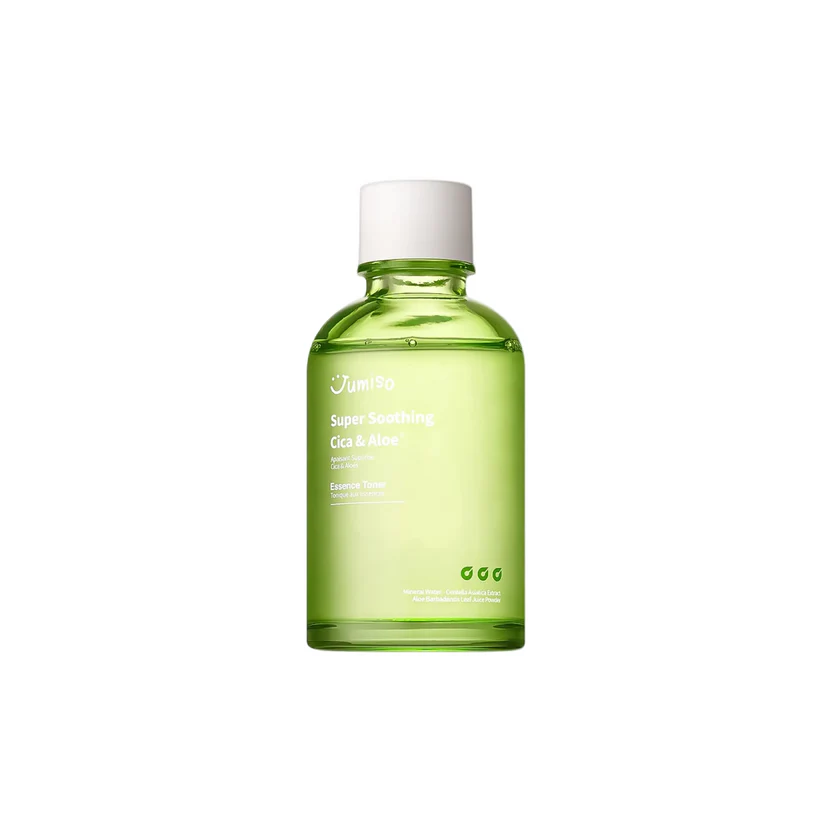
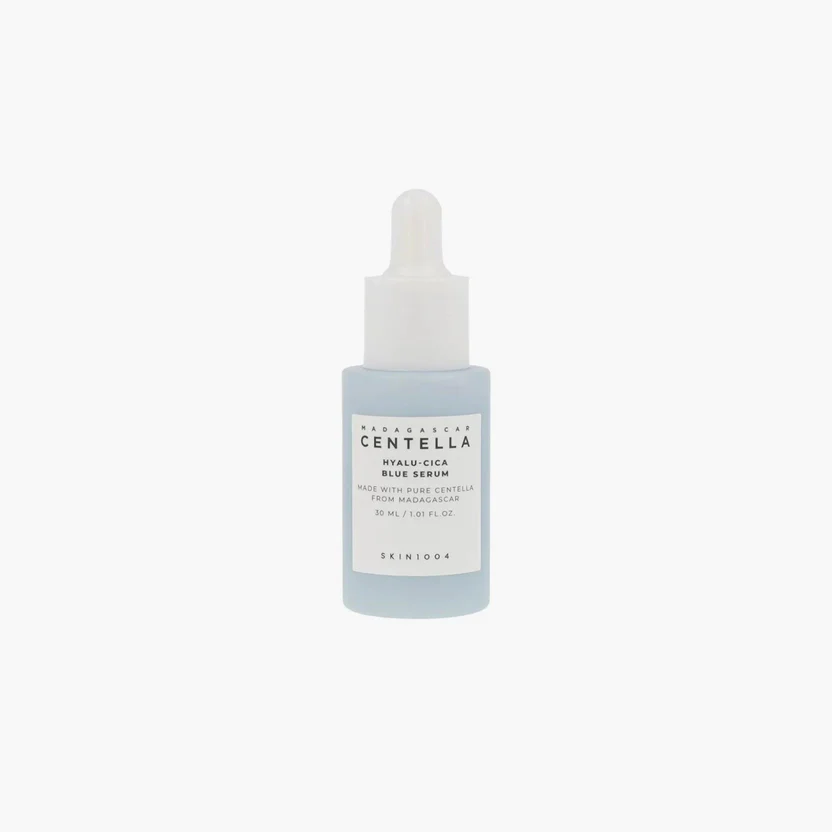
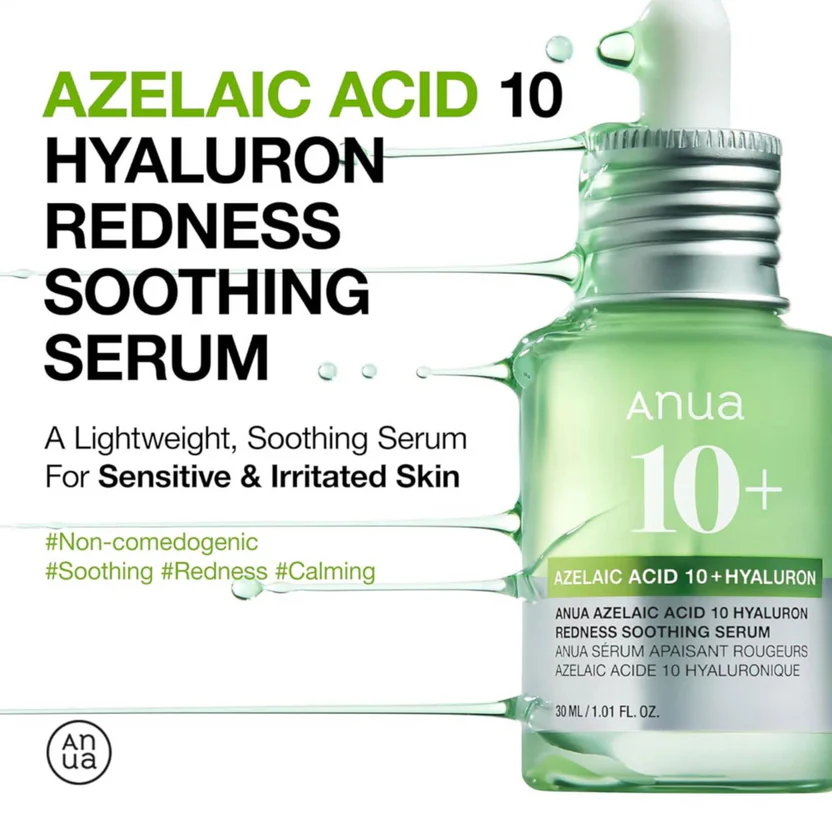
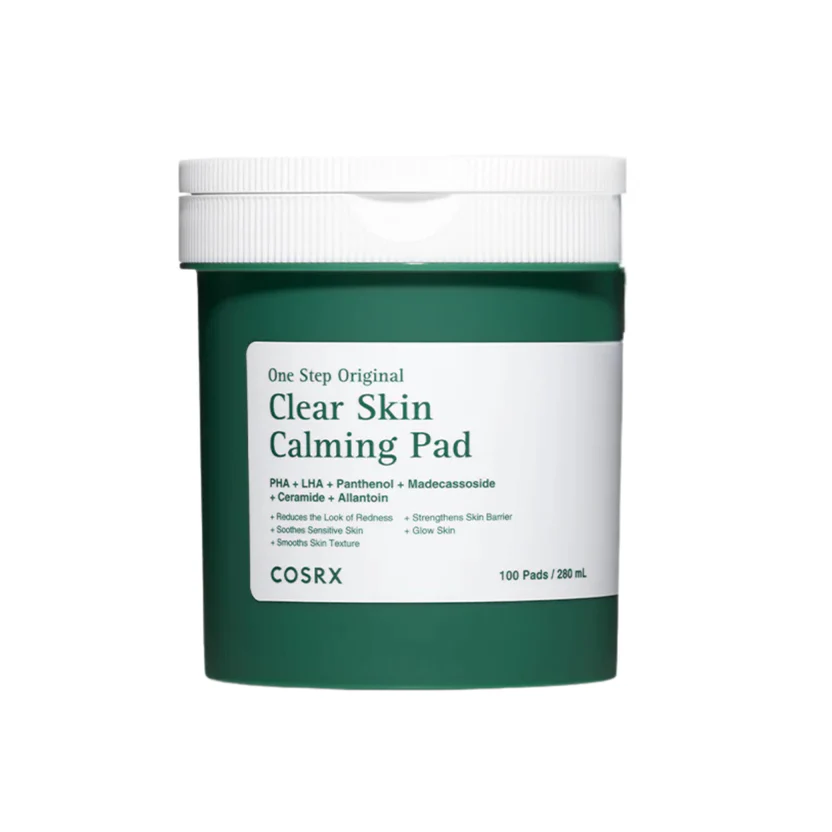
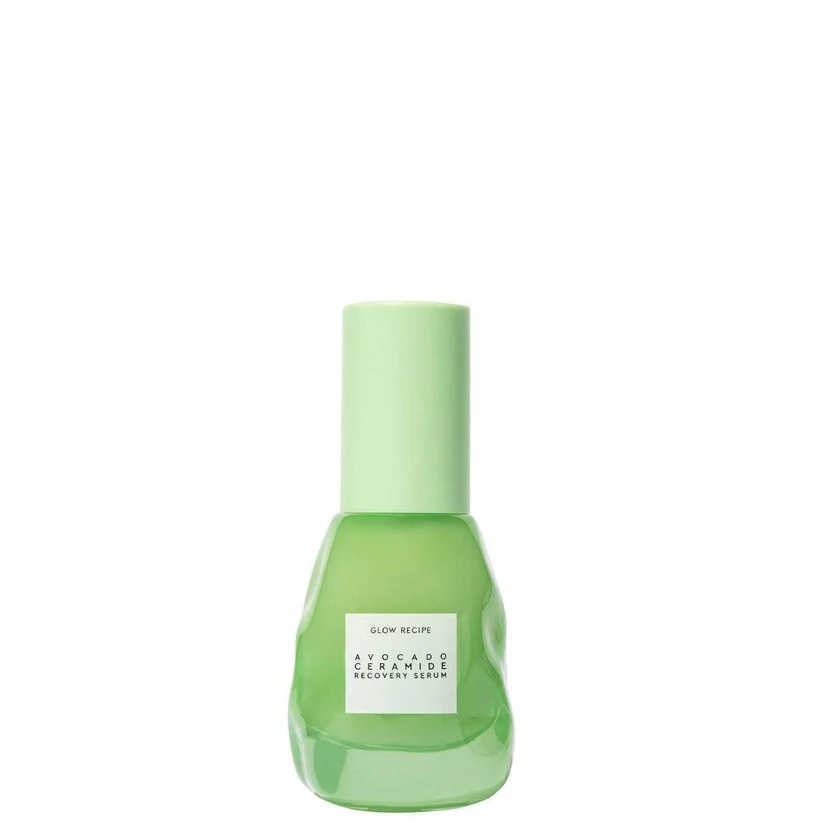
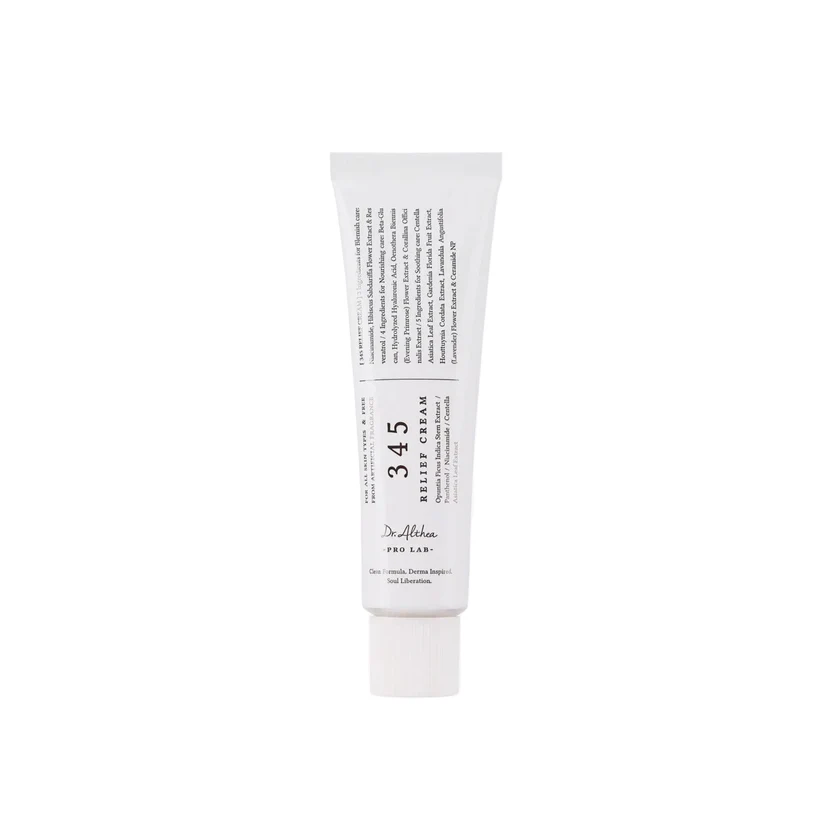
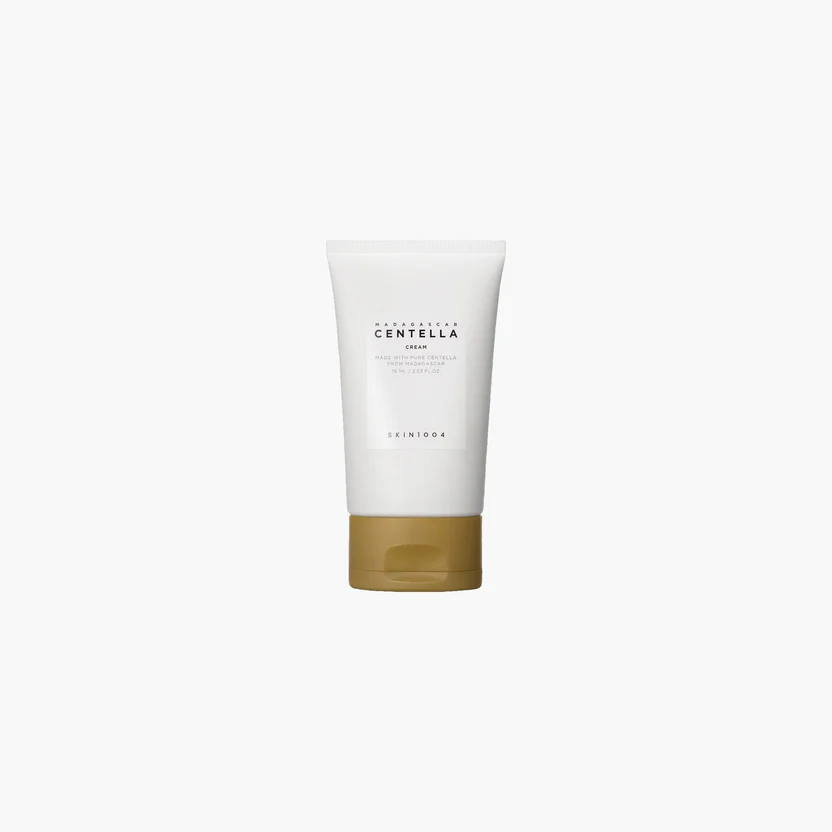
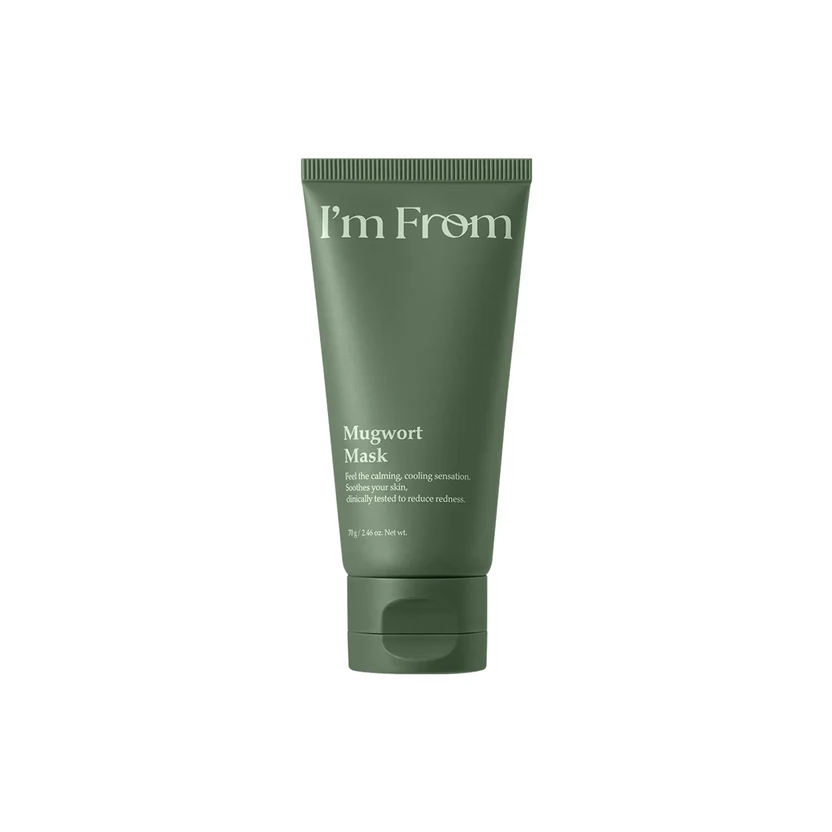
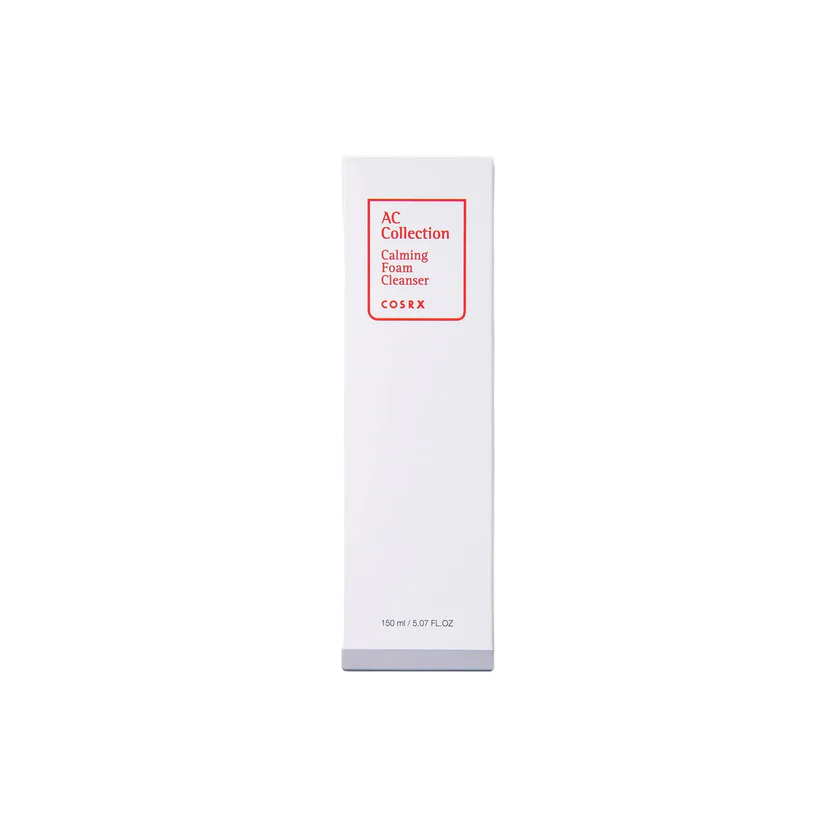
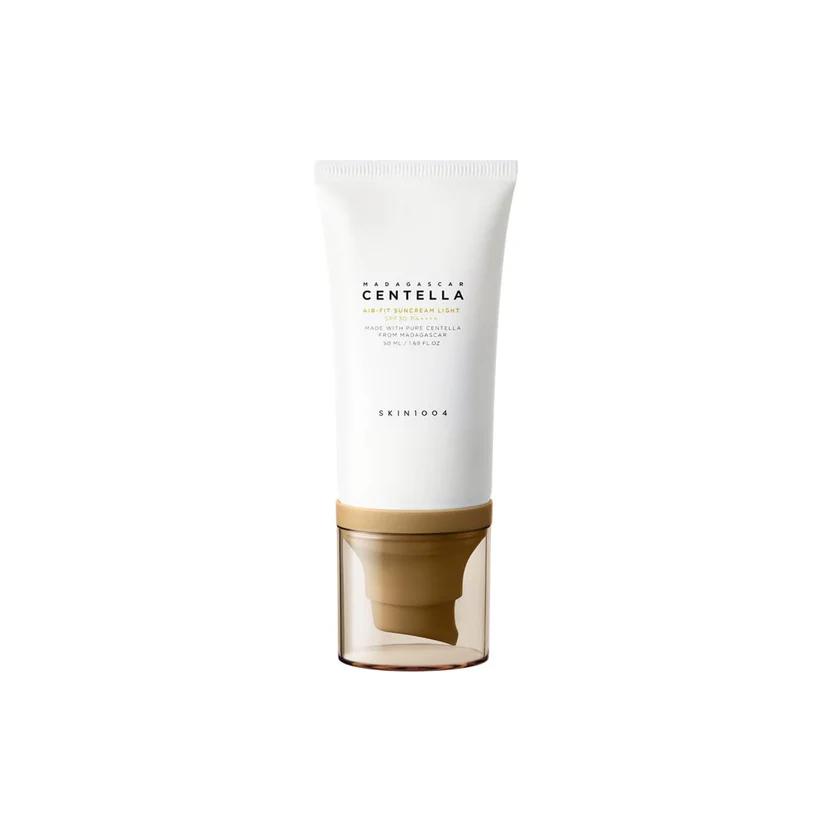
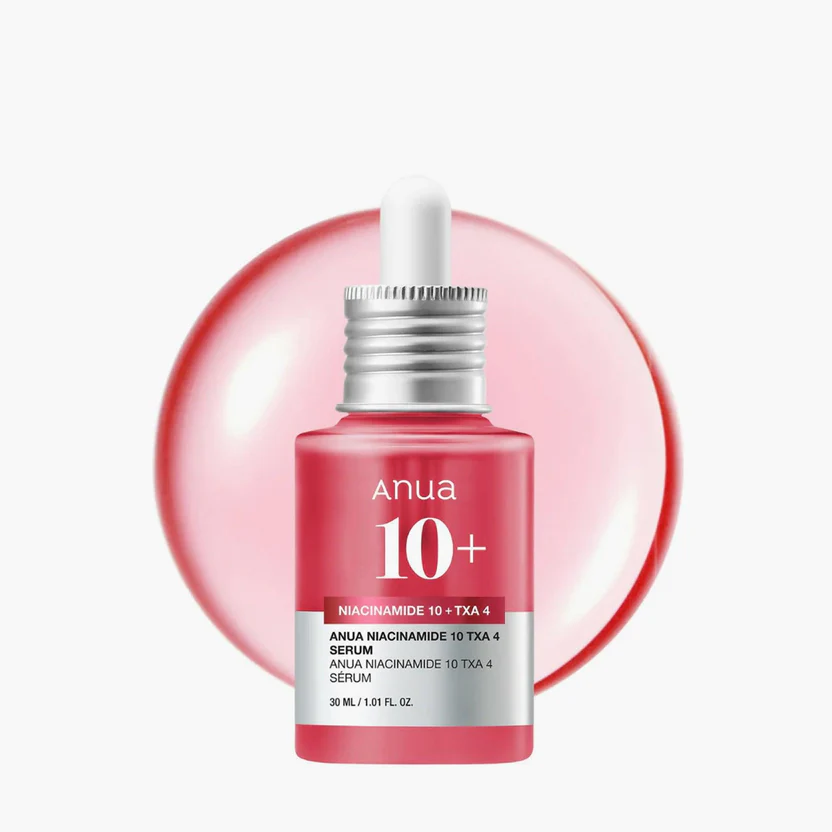
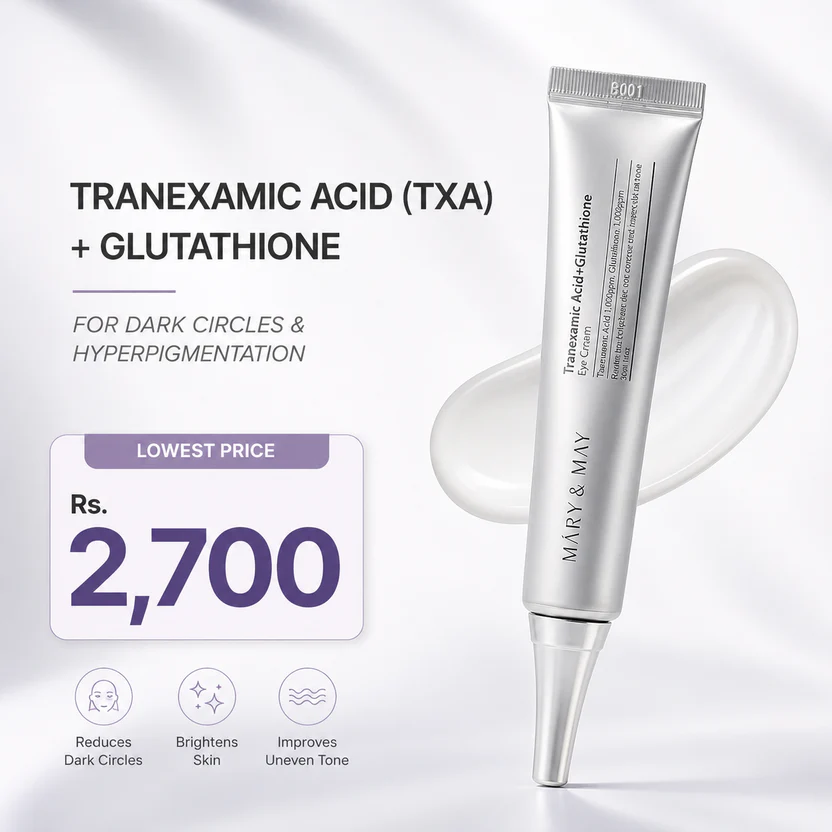
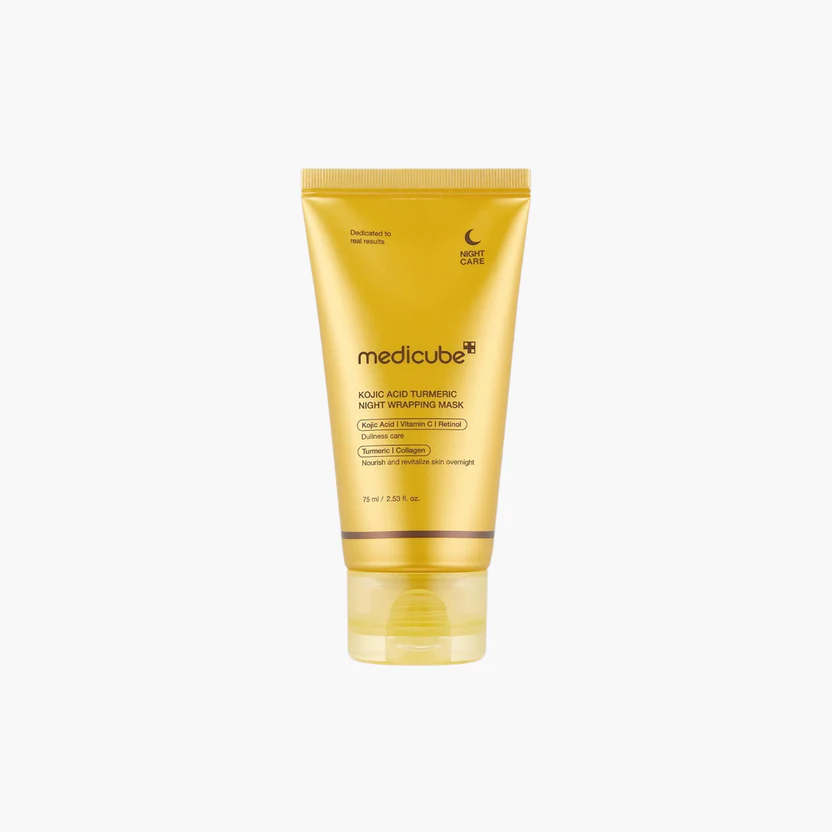
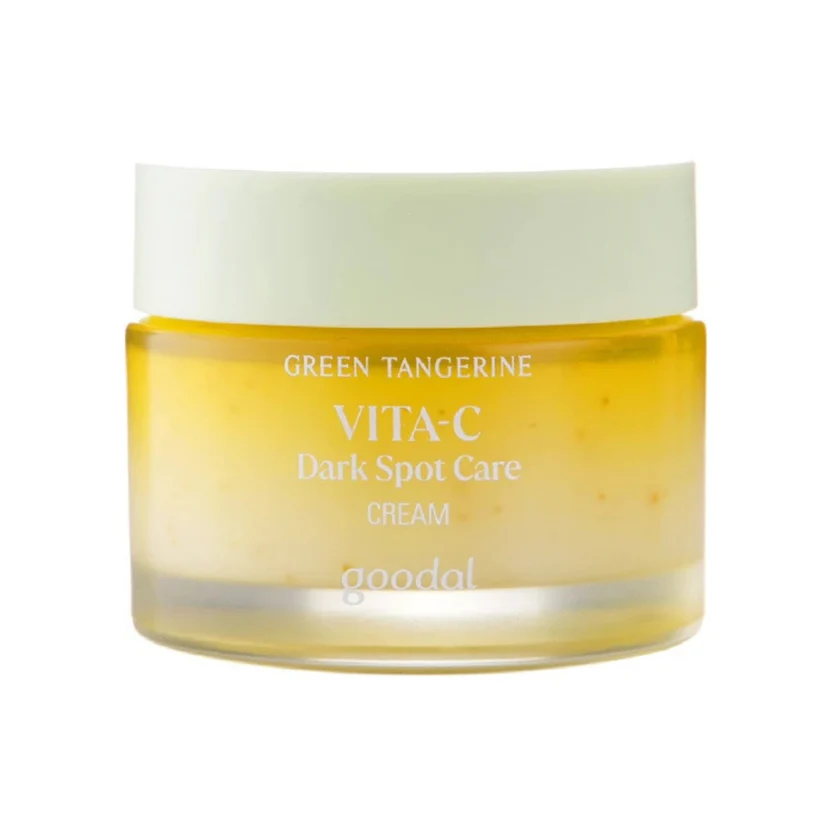
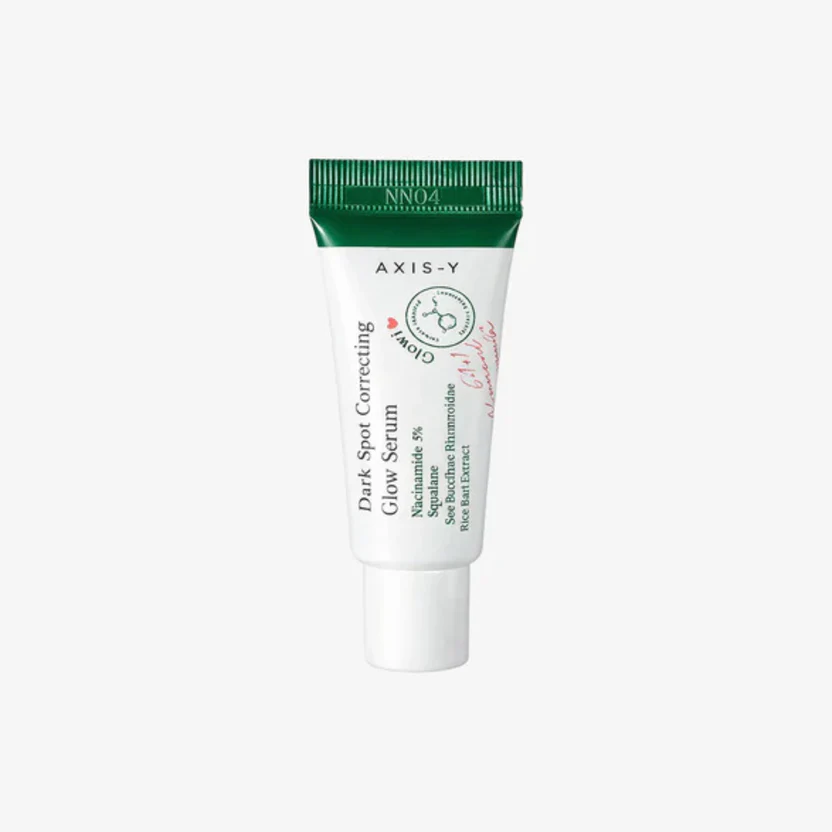
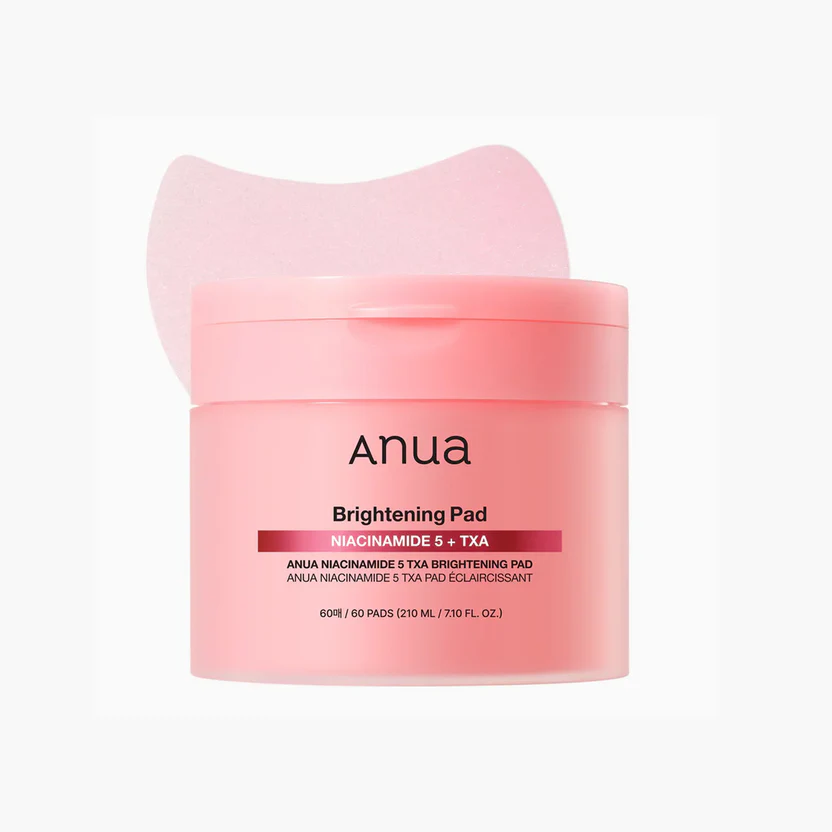
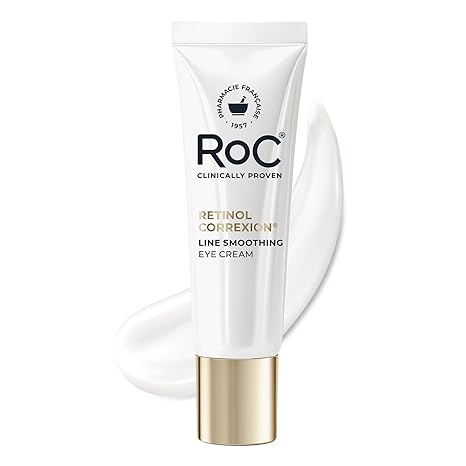
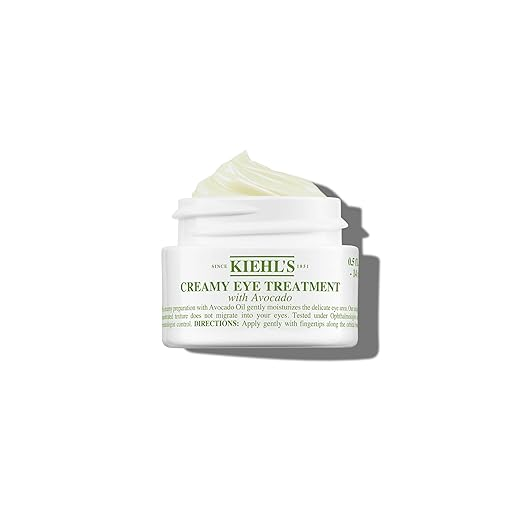
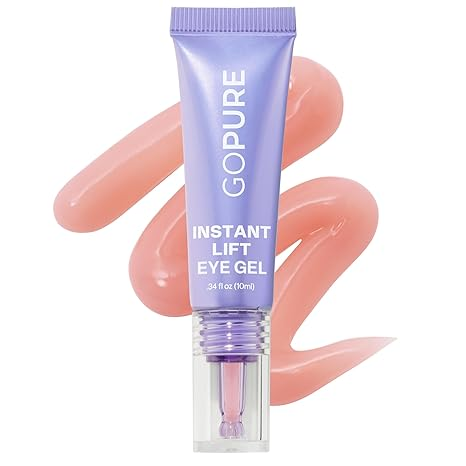
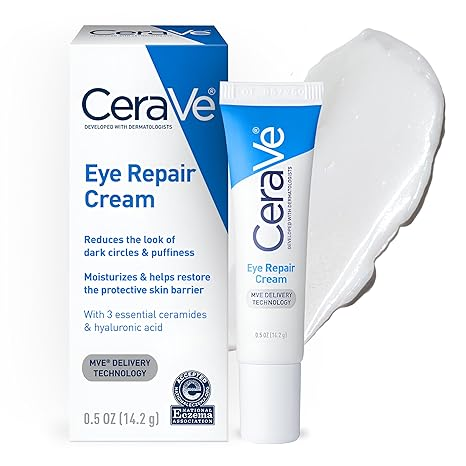
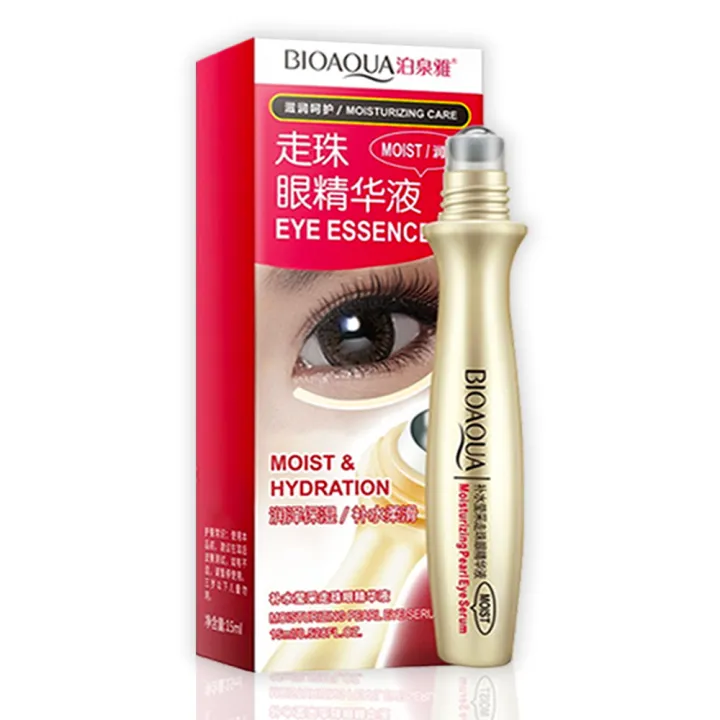
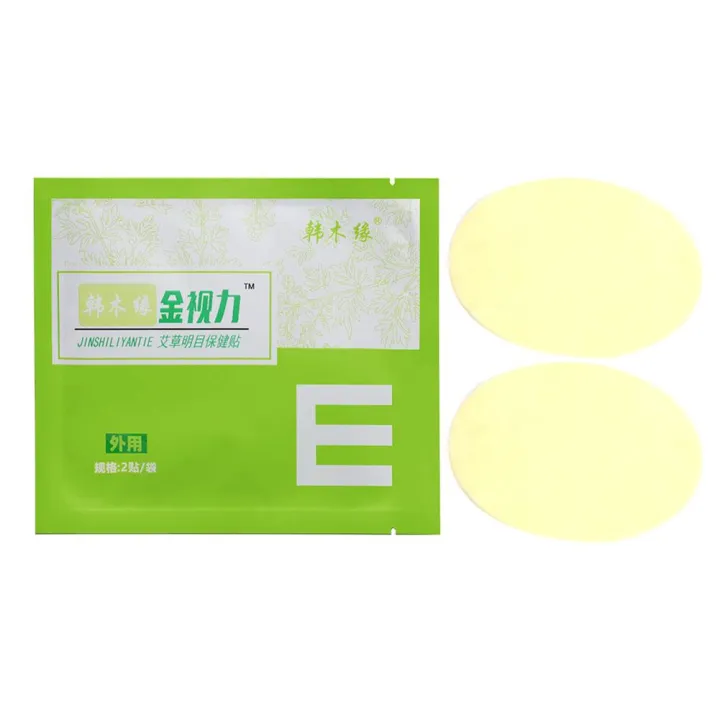
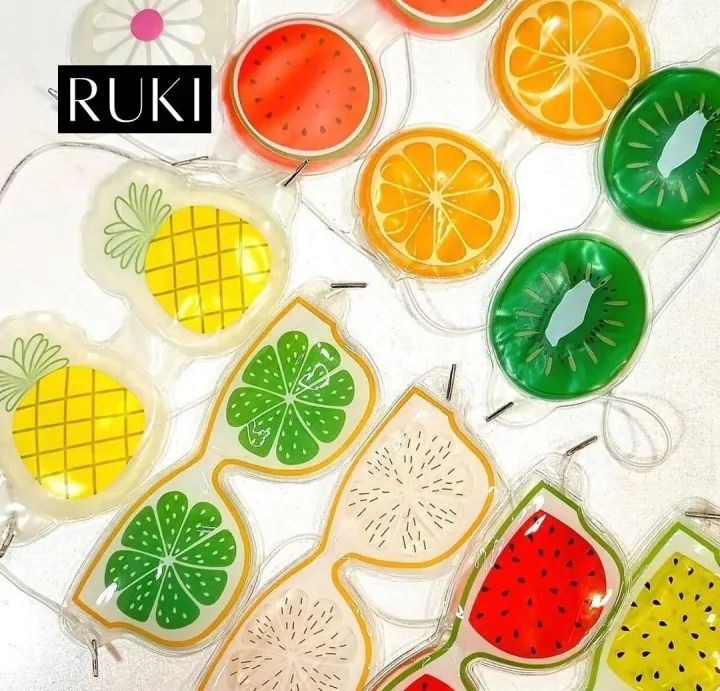
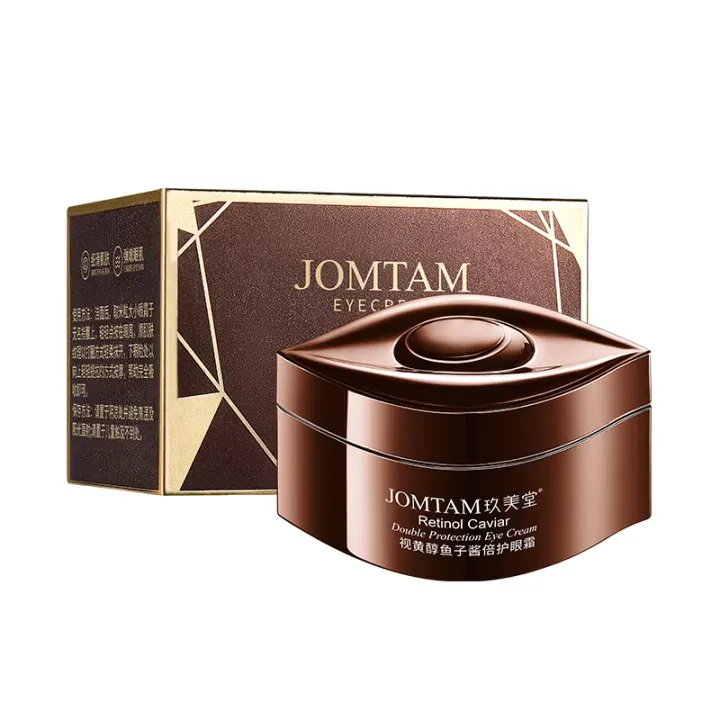
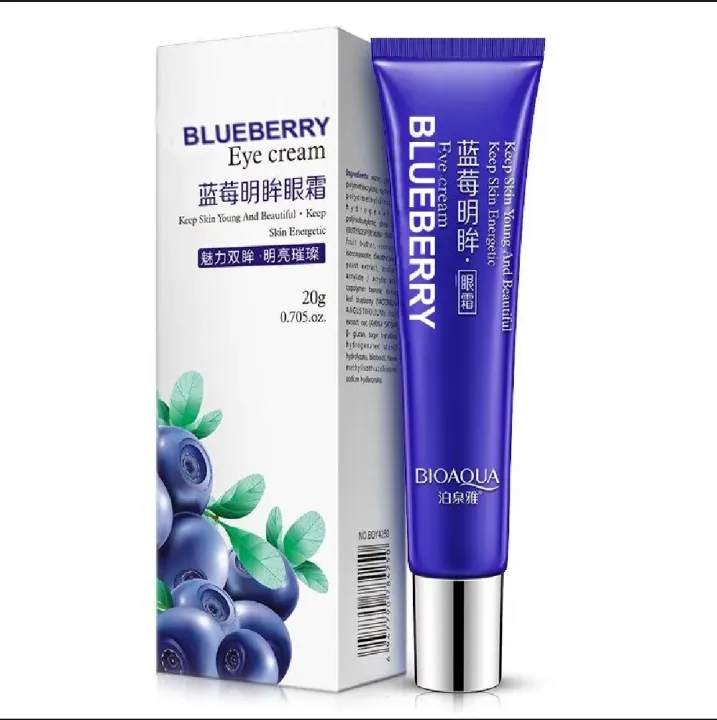
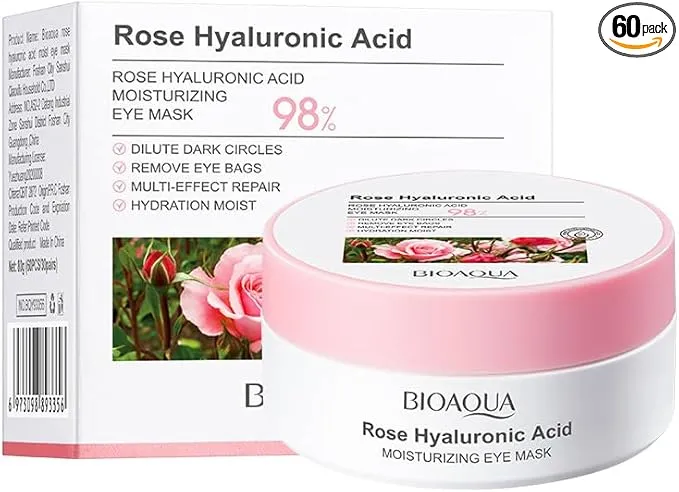

In [2]:
import os, shutil, base64, urllib.parse
import glob
from IPython.display import HTML, display
import json

SOURCE = "/content/drive/MyDrive/Products-for-Cure-Updated"
DEST = "/content/PFC-Updated"

if not os.path.exists(DEST):
    if os.path.exists(SOURCE):
        shutil.copytree(SOURCE, DEST)
        print("✅ Folder copied successfully!")
    else:
        print("❌ Error: Could not find 'Products-for-Cure-Updated' in your Drive.")
# 1. Define the root directory where your disease folders are located
# If they are in a folder named 'diseases', use root_path = 'diseases'
root_path = "PFC-Updated"

# 2. Get all subdirectories (folders) in that path
disease_folders = [f.path for f in os.scandir(root_path) if f.is_dir()]

def get_base64_image(img_path):
    """Helper to convert local images to base64 strings for Colab display."""
    try:
        with open(img_path, "rb") as image_file:
            encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
            # Determine mime type based on extension
            ext = img_path.split('.')[-1].lower()
            mime = f"image/{ext}" if ext != 'jpg' else "image/jpeg"
            return f"data:{mime};base64,{encoded_string}"
    except Exception:
        return ""

product_data = {}
for folder in disease_folders:
    disease_name = os.path.basename(folder)
    images = []
    for ext in ['jpg', 'jpeg', 'png', 'JPG', 'webp', 'avif']:
        images.extend(glob.glob(os.path.join(folder, f'*.{ext}')))

    items = []
    for img_path in images:
        file_name = os.path.splitext(os.path.basename(img_path))[0]
        clean_product_name = file_name.replace('_', ' ').title()
        b64_data = get_base64_image(img_path)
        items.append({
            "name": clean_product_name,
            "image": b64_data,
            "url": "https://google.com"
        })
    product_data[disease_name] = items

product_data_json = json.dumps(product_data)
html_code = """
<!DOCTYPE html>
<html>
<head>
  <title>Skin Disease Detector</title>
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <style>
    html, body {
      height: 100%;
      margin: 0;
      overflow-y: auto;
      -webkit-overflow-scrolling: touch;

      /* Firefox */
      scrollbar-width: none;
      /* IE / old Edge */
      -ms-overflow-style: none;
    }

    /* Chrome, Safari, new Edge */
    html::-webkit-scrollbar,
    body::-webkit-scrollbar {
      width: 0px;
      height: 0px;
      display: none;
    }
    body { font-family: Arial, sans-serif; max-width: 600px; margin: 40px auto; padding: 20px; }
    h2 { text-align: center; }
    video, img { width: 100%; border: 1px solid #ccc; border-radius: 8px; }
    button {
      display: block; width: 100%; padding: 12px;
      margin: 10px 0; font-size: 16px; cursor: pointer;
      background: #2a7ae2; color: white; border: none; border-radius: 6px;
    }
    button:hover { background: #1a5cbf; }
    #result {
            margin-top: 15px;
            font-size: 14px;
            color: #4a5568;
        }
    #status { text-align: center; color: gray; font-size: 14px; }
    #preview { display: none; margin-top: 10px; }
    /* --- Card Specific Layouts --- */
        .analysis-card {
            background: #ffffff;
            padding: 14px;
            border-radius: 12px;
            border: 1px solid #edf2f7;
            width: 100%;
            box-sizing: border-box;
            margin-top: 10px;
        }

        .card-header {
            margin-bottom: 12px;
            border-bottom: 1px solid #edf2f7;
            padding-bottom: 8px;
            overflow: hidden;
        }

        .card-header h2 {
            margin: 0;
            font-size: 1.1rem;
            font-weight: 700;
            float: left;
            color: #1a202c;
        }

        .status-badge {
            background-color: #def7ec;
            color: #03543f;
            padding: 2px 8px;
            border-radius: 10px;
            font-size: 0.75rem;
            font-weight: 600;
            float: right;
        }

        .main-prediction {
            background: linear-gradient(135deg, #e0e7ff, #f0f2ff) !important;
            padding: 12px;
            border-radius: 8px;
            text-align: center;
            margin-bottom: 14px;
            clear: both;
        }

        .main-prediction .label {
            font-size: 0.75rem;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            color: #4f46e5;
            font-weight: 700;
        }

        .main-prediction .value {
            font-size: 1.5rem;
            font-weight: 800;
            margin: 4px 0;
            color: #1a202c;
        }

        .main-prediction .confidence {
            font-size: 0.8rem;
            color: #4a5568;
        }

        .breakdown-title {
            font-size: 0.85rem;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            margin-top: 15px;
            margin-bottom: 10px;
            color: #4a5568;
        }

        .prediction-item {
            margin-bottom: 12px;
            display: block;
        }

        .item-info {
            overflow: hidden;
            margin-bottom: 4px;
            font-size: 0.85rem;
        }

        .item-name {
            font-weight: 600;
            float: left;
            color: #1a202c;
        }

        .item-percentage {
            color: #4a5568;
            font-weight: 700;
            float: right;
        }

        .progress-bar-container {
            background-color: #edf2f7 !important;
            border-radius: 4px;
            height: 8px;
            width: 100%;
            overflow: hidden;
            display: block;
            clear: both;
        }

        .progress-bar {
            background-color: #4f46e5 !important;
            display: block !important;
            height: 8px !important;
            border-radius: 4px;
        }

.dashboard-container {
    background: #ffffff;
    # width: 100%;
    max-width: 800px;
    padding: 40px;
    border-radius: 20px;
    box-shadow: 0 10px 30px rgba(0, 0, 0, 0.05);
    text-align: center;
}

/* Top Prediction Styling */
.top-prediction-section h2 {
    color: #2c3e50;
    margin-bottom: 20px;
}

.main-circle-container {
    position: relative;
    display: flex;
    justify-content: center;
    align-items: center;
    margin-bottom: 50px;
}

.main-circle {
    width: 200px;
    height: 200px;
    border-radius: 50%;
    background: linear-gradient(135deg, #ff5e62 0%, #ff9966 100%);
    display: flex;
    flex-direction: column;
    justify-content: center;
    align-items: center;
    color: white;
    box-shadow: 0 15px 35px rgba(255, 94, 98, 0.3);
    z-index: 2;
    transition: transform 0.3s ease;
}

.main-circle:hover {
    transform: scale(1.05);
}

.main-circle .percentage {
    font-size: 3rem;
    font-weight: bold;
}

.main-circle .label {
    font-size: 1.2rem;
    font-weight: 500;
    margin-top: 5px;
}

/* Sub Predictions Styling */
.sub-predictions-section h3 {
    color: #34495e;
    margin-bottom: 30px;
    text-align: left;
    padding-left: 20px;
    border-left: 5px solid #ff5e62;
}

.sub-circles-grid {
    display: flex;
    justify-content: space-around;
    align-items: center;
    flex-wrap: wrap;
    gap: 20px;
}

.sub-circle-wrapper {
    display: flex;
    flex-direction: column;
    align-items: center;
}

.sub-circle {
    width: 88px;
    height: 88px;
    border-radius: 50%;
    display: flex;
    justify-content: center;
    align-items: center;
    color: white;
    font-weight: bold;
    font-size: 1.2rem;
    box-shadow: 0 8px 20px rgba(0, 0, 0, 0.1);
    transition: transform 0.3s ease;
}

.sub-circle:hover {
    transform: translateY(-5px);
}

/* Different gradients for each sub circle */
.sc-1 { background: linear-gradient(135deg, #42e695 0%, #3bb2b8 100%); }
.sc-2 { background: linear-gradient(135deg, #7f00ff 0%, #e100ff 100%); }
.sc-3 { background: linear-gradient(135deg, #00c6ff 0%, #0072ff 100%); }
.sc-4 { background: linear-gradient(135deg, #f6d365 0%, #fda085 100%); }
.sc-5 { background: linear-gradient(135deg, #a1c4fd 0%, #c2e9fb 100%); }

.sub-label {
    margin-top: 15px;
    color: #7f8c8d;
    font-weight: 600;
    font-size: 0.95rem;
}

/* Responsive adjustments */
@media (max-width: 600px) {
    .main-circle { width: 150px; height: 150px; }
    .main-circle .percentage { font-size: 2.5rem; }
    .sub-circles-grid { flex-direction: column; }
    .sub-circle-wrapper { margin-bottom: 15px; }
}
  </style>
</head>
<body>
  <h2 style="
    margin-top: 60px;
">Skin Disease Detector</h2>

  <video id="video" autoplay playsinline></video>
  <img id="preview" alt="Captured photo">

  <button id="btn-camera">Open Camera</button>
  <button id="btn-capture" style="display:none;">Take Photo</button>
  <button id="btn-retake" style="display:none;">Retake</button>
  <button id="btn-analyze" style="display:none;">Analyze</button>

  <p id="status" style="margin-bottom: 40px;"></p>
  <div id="result"></div>
  <div id="cureprod"></div>
  <canvas id="canvas" style="display:none;"></canvas>

  <script>
    const PRODUCT_DATA = __PRODUCT_DATA_JSON__;
    let photoData = null;
    const formData = new FormData();
    function startCamera() {
      navigator.mediaDevices.getUserMedia({ video: { facingMode: 'environment' } })
        .then(stream => {
          document.getElementById('video').srcObject = stream;
          document.getElementById('btn-camera').style.display = 'none';
          document.getElementById('btn-capture').style.display = 'block';
        })
        .catch(() => alert('Camera access denied.'));
    }

    function capturePhoto() {
        const video = document.getElementById('video');
        const canvas = document.getElementById('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        photoData = canvas.toDataURL('image/jpeg').split(',')[1];

        const byteCharacters = atob(photoData);
        const byteNumbers = new Array(byteCharacters.length);
        for (let i = 0; i < byteCharacters.length; i++) {
            byteNumbers[i] = byteCharacters.charCodeAt(i);
        }
        const byteArray = new Uint8Array(byteNumbers);
        const blob = new Blob([byteArray], { type: 'image/jpeg' });

        window.currentFormData = new FormData();
        window.currentFormData.append('file', blob, 'canvas-image.jpg');
      video.srcObject.getTracks().forEach(t => t.stop());
      document.getElementById('video').style.display = 'none';
      document.getElementById('preview').src = 'data:image/jpeg;base64,' + photoData;
      document.getElementById('preview').style.display = 'block';
      document.getElementById('btn-capture').style.display = 'none';
      document.getElementById('btn-retake').style.display = 'block';
      document.getElementById('btn-analyze').style.display = 'block';
    }

    function retake() {
      photoData = null;
      document.getElementById('preview').style.display = 'none';
      document.getElementById('video').style.display = 'block';
      document.getElementById('btn-retake').style.display = 'none';
      document.getElementById('btn-analyze').style.display = 'none';
      document.getElementById('result').style.display = 'none';
      startCamera();
    }
    function getimages(top5) {
      let html_output = "";
      for (const pred of top5) {
        const disease_name = pred.class_name;
        const items = PRODUCT_DATA[disease_name];

        html_output += `<h2 style="border-bottom: 2px solid #333; padding-top: 20px;">Disease: ${disease_name}</h2>`;

        if (!items || items.length === 0) {
          html_output += `<p style="color: gray;">No images found in this folder.</p>`;
          continue;
        }

        for (const item of items) {
          html_output += `
            <div style="display: inline-block; text-align: center; margin: 10px; vertical-align: top;">
              <a href="${item.url}" target="_blank" style="text-decoration: none; color: inherit;">
                  <img src="${item.image}" width="150" height="150" style="object-fit: cover; border-radius: 10px; border: 1px solid #ddd;">
                  <p style="width: 150px; font-weight: bold; margin-top: 5px;">${item.name}</p>
                  <span style="color: #007bff; font-size: 12px;">View Product →</span>
              </a>
            </div>`;
        }
      }
      return html_output;
    }
    function resizeFrame() {
      if (window.google && google.colab && google.colab.output) {
        google.colab.output.setIframeHeight(0, true, {maxHeight: 5000});
      }
    }
    function analyze() {
      console.log("i am start")
      if (!photoData) return;
      console.log("i am here")
      document.getElementById('status').textContent = 'Analyzing...';
      document.getElementById('result').style.display = 'none';

      fetch('https://greeter-darling-prowess.ngrok-free.dev/predict', {
        method: 'POST',
        body: window.currentFormData
      })
      .then(r => r.json())
      .then(data => {
        console.log(data)
        document.getElementById('status').textContent = '';
        const result = document.getElementById('result');
        const cure_products = document.getElementById('cureprod');
        result.innerText = "";
        cure_products.innerText="";

         if(!data.success)
         {
            result.innerHTML = `
            <div style="display: flex; align-items: center; justify-content: center; font-family: 'Segoe UI', system-ui, -apple-system, sans-serif; background: #f8fafc; padding: 2rem; border-radius: 12px; border: 1px solid #e2e8f0; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.1); max-width: 400px; margin: 0 auto;">
              <div style="display: flex; align-items: center; gap: 16px;">
                <!-- Icon -->
                <div style="background: #eff6ff; color: #2563eb; padding: 12px; border-radius: 50%; display: flex; align-items: center; justify-content: center;">
                  <svg xmlns="http://w3.org" width="24" height="24" viewBox="0 0 24 24" fill="none" stroke="currentColor" stroke-width="2" stroke-linecap="round" stroke-linejoin="round">
                    <circle cx="12" cy="12" r="10"></circle>
                    <line x1="12" y1="8" x2="12" y2="12"></line>
                    <line x1="12" y1="16" x2="12.01" y2="16"></line>
                  </svg>
                </div>
                <!-- Message -->
                <div>
                  <h4 style="margin: 0 0 4px 0; font-size: 1.1rem; color: #1e293b; font-weight: 600;">No Skin Detected</h4>
                  <p style="margin: 0; font-size: 0.9rem; color: #64748b; line-height: 1.4;">${data.detail}.</p>
                </div>
              </div>
            </div>`
         }
        // Injecting the clean HTML card into our <div> container
        else{
            result.innerHTML = `
            <div class="dashboard-container">
            <!-- Top Prediction -->
            <div class="top-prediction-section">
                <h2>Top Prediction</h2>
                <div class="main-circle-container">
                    <div class="main-circle">
                        <span class="percentage">${(data.confidence * 100).toFixed(1)}%</span>
                        <span class="label">${data.prediction}</span>
                    </div>
                    <div class="circle-shadow"></div>
                </div>
            </div>

            <!-- Top 5 Predictions -->
            <div class="sub-predictions-section">
                <h3>Other Predictions</h3>
                <div class="sub-circles-grid">
                    <div class="sub-circle-wrapper">
                        <div class="sub-circle sc-1"><span>${(data.top_5[0].confidence*100).toFixed(1)}%</span></div>
                        <span class="sub-label">${data.top_5[0].class_name}</span>
                    </div>

                    <div class="sub-circle-wrapper">
                        <div class="sub-circle sc-2"><span>${(data.top_5[1].confidence*100).toFixed(1)}%</span></div>
                        <span class="sub-label">${data.top_5[1].class_name}</span>
                    </div>

                    <div class="sub-circle-wrapper">
                        <div class="sub-circle sc-3"><span>${(data.top_5[2].confidence*100).toFixed(1)}%</span></div>
                        <span class="sub-label">${data.top_5[2].class_name}</span>
                    </div>

                    <div class="sub-circle-wrapper">
                        <div class="sub-circle sc-4"><span>${(data.top_5[3].confidence*100).toFixed(1)}%</span></div>
                        <span class="sub-label">${data.top_5[3].class_name}</span>
                    </div>

                    <div class="sub-circle-wrapper">
                        <div class="sub-circle sc-5"><span>${(data.top_5[4].confidence*100).toFixed(1)}%</span></div>
                        <span class="sub-label">${data.top_5[4].class_name}</span>
                    </div>
                </div>
            </div>
        </div>`;

        const prodimages = getimages(data.top_5);
        cure_products.innerHTML = prodimages;
    }
       result.style.display = 'block';
       result.style.marginBottom = '50px';
       resizeFrame();
      })
      .catch(() => {
        document.getElementById('status').textContent = 'Error contacting server.';
      });
    }
    window.startCamera = startCamera;
    window.capturePhoto = capturePhoto;
    window.retake = retake;
    window.analyze = analyze;

    document.getElementById('btn-camera').addEventListener('click', startCamera);
    document.getElementById('btn-capture').addEventListener('click', capturePhoto);
    document.getElementById('btn-retake').addEventListener('click', retake);
    document.getElementById('btn-analyze').addEventListener('click', analyze);
  </script>

</body>
</html>"""
#resultBox.innerText = JSON.stringify(data, null, 2);
#result.textContent = data.result || data.error;
#result.innerText = JSON.stringify(data, null, 2);
#result.style.display = 'block';
#result {
      #margin-top: 20px; padding: 15px;
      #background: #f0f8ff; border: 1px solid #ccc;
      #border-radius: 8px; white-space: pre-wrap;
      #display: none;
    #}
html_code = html_code.replace("__PRODUCT_DATA_JSON__", product_data_json)
display(HTML(html_code))

In [ ]:
import os, shutil, base64, urllib.parse
import glob
from IPython.display import HTML, display
import json

SOURCE = "/content/drive/MyDrive/Products-for-Cure-Updated"
DEST = "/content/PFC-Updated"

if not os.path.exists(DEST):
    if os.path.exists(SOURCE):
        shutil.copytree(SOURCE, DEST)
        print("✅ Folder copied successfully!")
    else:
        print("❌ Error: Could not find 'Products-for-Cure-Updated' in your Drive.")
# 1. Define the root directory where your disease folders are located
# If they are in a folder named 'diseases', use root_path = 'diseases'
root_path = "PFC-Updated"

# 2. Get all subdirectories (folders) in that path
disease_folders = [f.path for f in os.scandir(root_path) if f.is_dir()]

product_data = {}
for folder in disease_folders:
    disease_name = os.path.basename(folder)
    images = []
    for ext in ['jpg', 'jpeg', 'png', 'JPG', 'webp', 'avif']:
        images.extend(glob.glob(os.path.join(folder, f'*.{ext}')))

    items = []
    for img_path in images:
        file_name = os.path.splitext(os.path.basename(img_path))[0]
        clean_product_name = file_name.replace('_', ' ').title()

        items.append({
            "name": clean_product_name,
            "image": img_path,
            "url": "https://google.com"
        })
    product_data[disease_name] = items
with open('productData.js', 'w') as f:
    f.write('export const productData = ' + json.dumps(product_data, indent=2) + ';\n')

✅ Folder copied successfully!
